In [399]:
import pandas as pd
import matplotlib
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np  # likely needed too

# Clear and rebuild cache
import json
import glob
import shutil, os
cache = matplotlib.get_cachedir()
shutil.rmtree(cache, ignore_errors=True)
os.makedirs(cache, exist_ok=True)

# Manually register DejaVu fonts
font_dir = "/opt/homebrew/lib/python3.11/site-packages/matplotlib/mpl-data/fonts/ttf"
for ttf in os.listdir(font_dir):
    if ttf.endswith(".ttf"):
        fm.fontManager.addfont(os.path.join(font_dir, ttf))

# Set as default
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

HEAD_ONLY_BACKBONE_EVAL_TASKS = {
    'canc_type_class', 'canc_type_class_33', 'deconv', 'disease_class',
    'drug_resp', 'gene_essent', 'surv_pred', 'surv_pred_binary',
    'surv_pred_survboard',
}


def head_only_output_is_current(base, task, mode):
    if task not in HEAD_ONLY_BACKBONE_EVAL_TASKS or mode == 'pca_rf':
        return True
    metadata_path = f'{base}/{mode}/{task}_{mode}_run_metadata.json'
    metrics_path = f'{base}/{mode}/{task}_{mode}_evaluation_metrics.csv'
    if os.path.exists(metadata_path) and os.path.exists(metrics_path):
        with open(metadata_path) as handle:
            metadata = json.load(handle)
        valid_head_only = (
            mode != 'head_only' or metadata.get('head_only_backbone_eval') is True
        )
        if metadata.get('run_status') == 'complete' and valid_head_only:
            return True
    print(f'Skipping incomplete or incompatible output for {task}/{mode}')
    return False


def completed_output_is_current(base, task, variant):
    metadata_path = f'{base}/{variant}/{task}_{variant}_run_metadata.json'
    if not os.path.exists(metadata_path):
        return False
    with open(metadata_path) as handle:
        metadata = json.load(handle)
    return metadata.get('run_status') == 'complete'

print("Fonts loaded, good to go!")


Fonts loaded, good to go!


## Pretraining

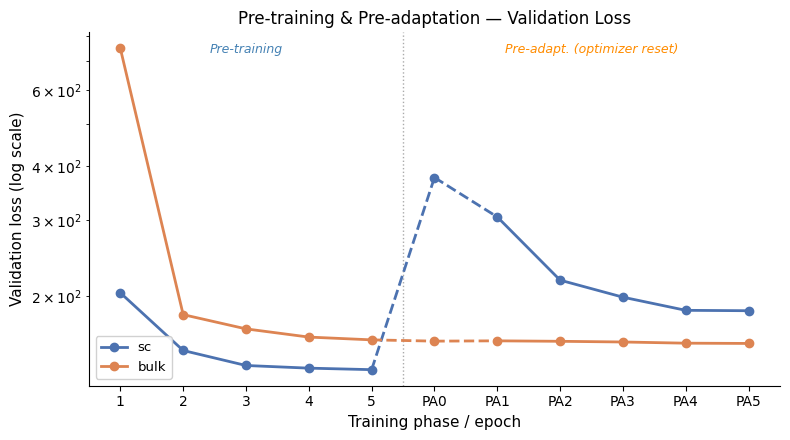

In [400]:
root = os.path.expanduser("~/Thesis/eheiss/output")

def load_val(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    val = df[df["split"] == "val"].reset_index(drop=True)
    return val if not val.empty else None

series = {
    "sc": {
        "pretrain": load_val(f"{root}/pretrain_sc/pretrain_sc_pretrain_epoch_metrics.csv"),
        "pa0": load_val(f"{root}/preadapt_sc/preadapt_sc_pa0_epoch_metrics.csv"),
        "preadapt": load_val(f"{root}/preadapt_sc/preadapt_sc_pretrain_epoch_metrics.csv"),
        "color": "#4C72B0",
    },
    "bulk": {
        "pretrain": load_val(f"{root}/pretrain_bulk/pretrain_bulk_pretrain_epoch_metrics.csv"),
        "pa0": load_val(f"{root}/preadapt_bulk/preadapt_bulk_pa0_epoch_metrics.csv"),
        "preadapt": load_val(f"{root}/preadapt_bulk/preadapt_bulk_pretrain_epoch_metrics.csv"),
        "color": "#DD8452",
    },
}
series = {name: values for name, values in series.items()
          if any(values[key] is not None for key in ("pretrain", "pa0", "preadapt"))}
if not series:
    raise FileNotFoundError(f"No pre-training, PA0, or pre-adaptation metric files found under {root}")

pretrain_epochs = sorted({epoch for values in series.values()
                          if values["pretrain"] is not None
                          for epoch in values["pretrain"]["epoch"]})
pretrain_end = max(pretrain_epochs, default=0)
has_pa0 = any(values["pa0"] is not None for values in series.values())
pa0_tick = pretrain_end + 1 if has_pa0 else None
preadapt_epochs = sorted({epoch for values in series.values()
                          if values["preadapt"] is not None
                          for epoch in values["preadapt"]["epoch"]})
preadapt_offset = pretrain_end + (1 if has_pa0 else 0)
preadapt_ticks = [preadapt_offset + epoch for epoch in preadapt_epochs]
sep = pretrain_end + 0.5

fig, ax = plt.subplots(figsize=(8, 4.5))

for name, values in series.items():
    df_pt = values["pretrain"]
    df_pa0 = values["pa0"]
    df_pa = values["preadapt"]
    color = values["color"]
    last_x = None
    last_y = None

    if df_pt is not None:
        ax.plot(df_pt["epoch"], df_pt["loss"], color=color, marker="o",
                lw=2, zorder=3, label=name)
        last_x = float(df_pt["epoch"].iloc[-1])
        last_y = float(df_pt["loss"].iloc[-1])

    if df_pa0 is not None and pa0_tick is not None:
        pa0_loss = float(df_pa0["loss"].iloc[0])
        if last_x is not None:
            ax.plot([last_x, pa0_tick], [last_y, pa0_loss],
                    color=color, lw=2, ls="--", zorder=3)
        ax.plot([pa0_tick], [pa0_loss], color=color, marker="o", lw=0, zorder=4,
                label=name if df_pt is None else "_nolegend_")
        last_x = float(pa0_tick)
        last_y = pa0_loss

    if df_pa is not None:
        pa_x = preadapt_offset + df_pa["epoch"].to_numpy()
        if last_x is not None:
            ax.plot([last_x, pa_x[0]], [last_y, df_pa["loss"].iloc[0]],
                    color=color, lw=2, ls="--", zorder=3)
        ax.plot(pa_x, df_pa["loss"], color=color, marker="o", lw=2, zorder=3,
                label=name if df_pt is None and df_pa0 is None else "_nolegend_")

if pretrain_epochs and (has_pa0 or preadapt_epochs):
    ax.axvline(sep, color="#aaaaaa", ls=":", lw=1)
if pretrain_epochs:
    ax.text(np.mean(pretrain_epochs), 0.97, "Pre-training",
            transform=ax.get_xaxis_transform(), ha="center", va="top",
            fontsize=9, color="steelblue", style="italic")
pa_phase_ticks = ([pa0_tick] if pa0_tick is not None else []) + preadapt_ticks
if pa_phase_ticks:
    ax.text(np.mean(pa_phase_ticks), 0.97, "Pre-adapt. (optimizer reset)",
            transform=ax.get_xaxis_transform(), ha="center", va="top",
            fontsize=9, color="darkorange", style="italic")

xticks = pretrain_epochs + ([pa0_tick] if pa0_tick is not None else []) + preadapt_ticks
xlabels = [str(e) for e in pretrain_epochs] + (["PA0"] if pa0_tick is not None else []) + [f"PA{e}" for e in preadapt_epochs]
ax.set_yscale("log")
ax.set_xticks(xticks)
ax.set_xticklabels(xlabels)
ax.set_xlabel("Training phase / epoch", fontsize=11)
ax.set_ylabel("Validation loss (log scale)", fontsize=11)
ax.set_title("Pre-training & Pre-adaptation — Validation Loss", fontsize=12)
ax.legend(loc="lower left", fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### scGPT pre-adaptation

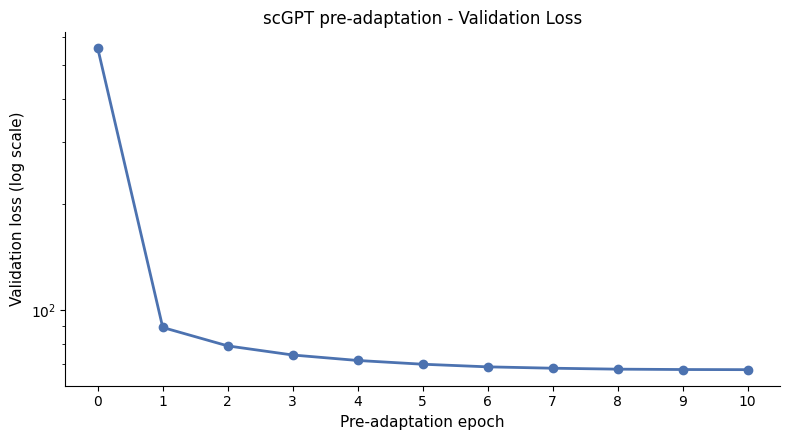

In [401]:
scgpt_preadapt_path = f"{root}/scgpt_preadapt/scgpt_preadapt_epoch_metrics.csv"
if not os.path.exists(scgpt_preadapt_path):
    raise FileNotFoundError(f"No scGPT pre-adaptation metrics found at {scgpt_preadapt_path}")

scgpt_preadapt_metrics = pd.read_csv(scgpt_preadapt_path)
required_columns = {"epoch", "split", "scope", "loss"}
missing_columns = required_columns.difference(scgpt_preadapt_metrics.columns)
if missing_columns:
    raise ValueError(f"scGPT pre-adaptation metrics are missing columns: {sorted(missing_columns)}")

scgpt_validation = (
    scgpt_preadapt_metrics[
        (scgpt_preadapt_metrics["split"] == "validation")
        & (scgpt_preadapt_metrics["scope"] == "all")
    ]
    .sort_values("epoch")
    .reset_index(drop=True)
)
if scgpt_validation.empty:
    raise ValueError("No overall validation rows found in the scGPT pre-adaptation metrics.")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(
    scgpt_validation["epoch"],
    scgpt_validation["loss"],
    color="#4C72B0",
    marker="o",
    lw=2,
)
epochs = scgpt_validation["epoch"].astype(int).tolist()
ax.set_yscale("log")
ax.set_xticks(epochs)
ax.set_xlabel("Pre-adaptation epoch", fontsize=11)
ax.set_ylabel("Validation loss (log scale)", fontsize=11)
ax.set_title("scGPT pre-adaptation - Validation Loss", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


### Bulk pretraining dataset-size comparison

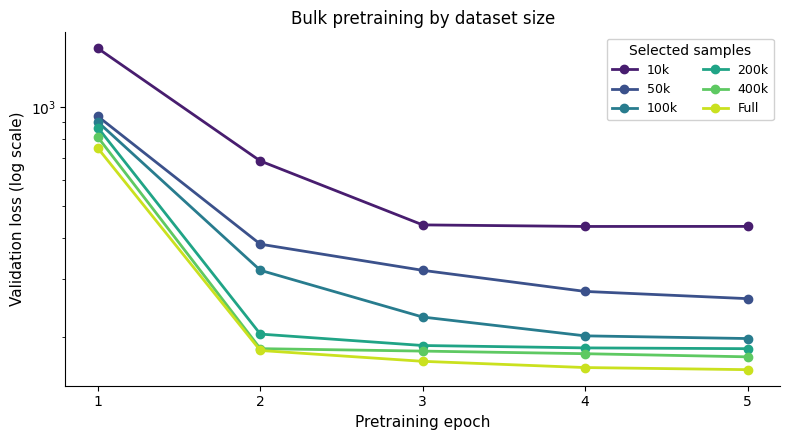

In [402]:
bulk_scale_specs = [
    ("10k", ("pretrain_bulk_10k",)),
    ("50k", ("pretrain_bulk_50k",)),
    ("100k", ("pretrain_bulk_100k",)),
    ("200k", ("pretrain_bulk_200k",)),
    ("400k", ("pretrain_bulk_400k",)),
    ("Full", ("pretrain_bulk",)),
]

bulk_scale_series = {}
for label, model_names in bulk_scale_specs:
    for model_name in model_names:
        path = f"{root}/{model_name}/{model_name}_pretrain_epoch_metrics.csv"
        values = load_val(path)
        if values is not None:
            bulk_scale_series[label] = values
            break

if not bulk_scale_series:
    raise FileNotFoundError(f"No bulk pretraining scale metrics found under {root}")

colors = plt.get_cmap("viridis")(
    np.linspace(0.08, 0.92, len(bulk_scale_series))
)
fig, ax = plt.subplots(figsize=(8, 4.5))
for (label, values), color in zip(bulk_scale_series.items(), colors):
    ax.plot(
        values["epoch"],
        values["loss"],
        color=color,
        marker="o",
        lw=2,
        label=label,
    )

epochs = sorted({
    int(epoch)
    for values in bulk_scale_series.values()
    for epoch in values["epoch"]
})
ax.set_yscale("log")
ax.set_xticks(epochs)
ax.set_xlabel("Pretraining epoch", fontsize=11)
ax.set_ylabel("Validation loss (log scale)", fontsize=11)
ax.set_title("Bulk pretraining by dataset size", fontsize=12)
ax.legend(title="Selected samples", ncol=2, fontsize=9, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Cancer classification (5 types)

In [403]:
bulkrnabert_weighted_f1_mean = 0.993
bulkrnabert_weighted_f1_sd = 0.004


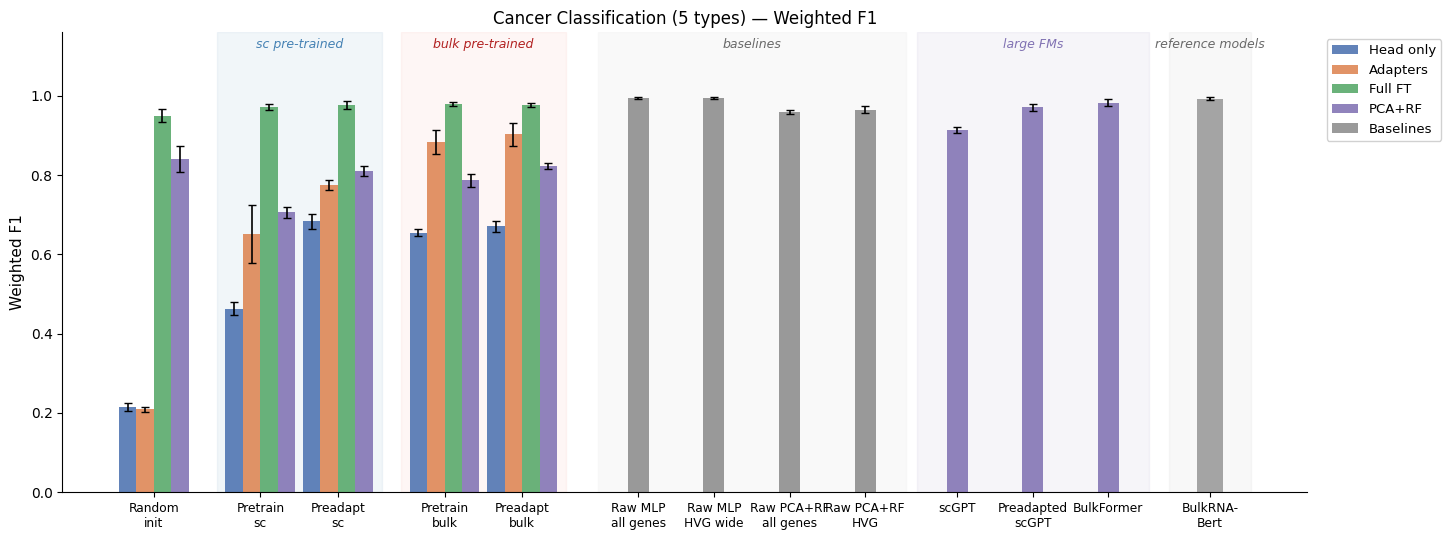

In [404]:
task = "canc_type_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft", "pca_rf"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT", "pca_rf": "PCA+RF"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868", "pca_rf": "#8172B3"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "f1_weighted_mean"
metric_std = "f1_weighted_std"

baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_pca_rf_all_genes", "Raw PCA+RF\nall genes"),
    ("raw_pca_rf_hvg1199", "Raw PCA+RF\nHVG"),
]
large_fm_specs = [
    ("scgpt_pca_rf", "scGPT"),
    ("scgpt_preadapt_pca_rf", "Preadapted\nscGPT"),
    ("bulkformer_pca_rf", "BulkFormer"),
]

def load_eval_csv(path):
    if os.path.exists(path):
        return pd.read_csv(path, comment="#").set_index("model")
    return None


def load_mode(mode):
    if not head_only_output_is_current(base, task, mode):
        return None
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    df = load_eval_csv(combined)
    if df is not None:
        return df
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None


def load_variant_metrics(specs, metric_col):
    loaded = {}
    for spec in specs:
        canonical = spec[0]
        if not completed_output_is_current(base, task, canonical):
            print(f'Skipping stale or partial result: {canonical}')
            continue
        path = f"{base}/{canonical}/{task}_{canonical}_evaluation_metrics.csv"
        df = load_eval_csv(path)
        if df is not None and metric_col in df.columns:
            loaded[canonical] = df
    return loaded


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = load_variant_metrics(baseline_specs, metric_mean)
large_fm_dfs = load_variant_metrics(large_fm_specs, metric_mean)
available_baselines = [variant for variant, _ in baseline_specs if variant in baseline_dfs]
available_large_fms = [variant for variant, _label in large_fm_specs if variant in large_fm_dfs]
if not available_modes and not available_baselines and not available_large_fms:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.18
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}
baseline_start = 5.0
baseline_spacing = 0.78
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}
large_fm_start = (max(baseline_x.values()) + 0.95) if baseline_x else 5.0
large_fm_spacing = 0.78
large_fm_x = {variant: large_fm_start + i * large_fm_spacing for i, variant in enumerate(available_large_fms)}
rightmost_nonref = max(
    list(baseline_x.values())
    + list(large_fm_x.values())
    + [centers["preadapt_bulk"]]
)
brnabert_x = rightmost_nonref + 1.05

fig, ax = plt.subplots(figsize=(17, 5.5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    for model, xc in centers.items():
        df = dfs[mode]
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        lbl = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in baseline_dfs:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

for variant, label in large_fm_specs:
    if variant not in large_fm_dfs or variant not in large_fm_x:
        continue
    row = large_fm_dfs[variant].loc["raw_mlp"] if "raw_mlp" in large_fm_dfs[variant].index else large_fm_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(large_fm_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8172B3", alpha=0.88,
           label="_nolegend_",
           error_kw={"linewidth": 1.2})

ax.bar(brnabert_x, bulkrnabert_weighted_f1_mean, bar_w * 1.5,
       yerr=bulkrnabert_weighted_f1_sd, capsize=3,
       color="#999999", alpha=0.88, label="_nolegend_")

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
baseline_lo = (min(baseline_x.values()) - 0.42) if baseline_x else None
baseline_hi = (max(baseline_x.values()) + 0.42) if baseline_x else None
large_fm_lo = (min(large_fm_x.values()) - 0.42) if large_fm_x else None
large_fm_hi = (max(large_fm_x.values()) + 0.42) if large_fm_x else None
ref_lo, ref_hi = brnabert_x - 0.42, brnabert_x + 0.42
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
if baseline_x:
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
if large_fm_x:
    ax.axvspan(large_fm_lo, large_fm_hi, alpha=0.07, color="#8172B3", zorder=0)
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)

y_lim = (0, 1.16)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.015, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.015, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.015, "baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")
if large_fm_x:
    ax.text((large_fm_lo + large_fm_hi) / 2, y_lim[1] - 0.015, "large FMs", ha="center", va="top", fontsize=9, color="#8172B3", style="italic")
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.015, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

large_fm_label_map = {variant: label for variant, label in large_fm_specs}
tick_pos = (
    list(centers.values())
    + list(baseline_x.values())
    + [large_fm_x[v] for v in available_large_fms]
    + [brnabert_x]
)
tick_labels = (
    ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"]
    + [dict(baseline_specs)[v] for v in available_baselines]
    + [large_fm_label_map[v] for v in available_large_fms]
    + ["BulkRNA-\nBert"]
)
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.8)
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Cancer Classification (5 types) — Weighted F1", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout(rect=(0, 0, 0.86, 1))
plt.show()


### Bulk pretraining dataset-size downstream comparison

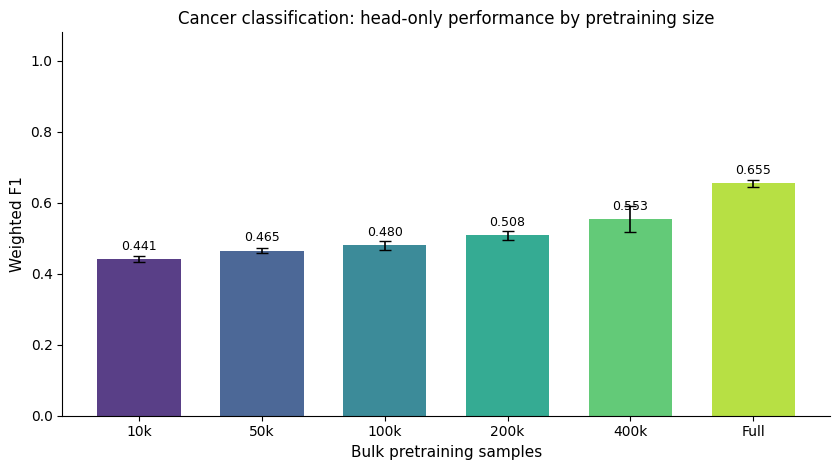

In [405]:
task = "canc_type_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
metric_mean = "f1_weighted_mean"
metric_std = "f1_weighted_std"

bulk_downstream_specs = [
    ("10k", "head_only_pretrain_bulk_10k"),
    ("50k", "head_only_pretrain_bulk_50k"),
    ("100k", "head_only_pretrain_bulk_100k"),
    ("200k", "head_only_pretrain_bulk_200k"),
    ("400k", "head_only_pretrain_bulk_400k"),
    ("Full", None),
]


def load_bulk_downstream_result(label, variant):
    if label == "Full":
        metadata_path = f"{base}/head_only/{task}_head_only_run_metadata.json"
        candidates = [
            f"{base}/head_only/{task}_head_only_pretrain_bulk_evaluation_metrics.csv",
            f"{base}/head_only/{task}_head_only_evaluation_metrics.csv",
        ]
    else:
        prefix = f"{task}_{variant}"
        metadata_path = f"{base}/{variant}/{prefix}_run_metadata.json"
        candidates = [
            f"{base}/{variant}/{prefix}_evaluation_metrics.csv",
            f"{base}/{variant}/{prefix}_pretrain_bulk_evaluation_metrics.csv",
        ]

    if not os.path.exists(metadata_path):
        return None, None, None
    with open(metadata_path) as handle:
        metadata = __import__("json").load(handle)
    if (
        metadata.get("head_only_backbone_eval") is not True
        or metadata.get("run_status") != "complete"
    ):
        print(f"Skipping incomplete or incompatible head-only result: {label}")
        return None, None, None
    fold_fingerprint = metadata.get("cv_fold_fingerprint")
    if not fold_fingerprint:
        print(f"Skipping head-only result without fold fingerprint: {label}")
        return None, None, None

    for path in candidates:
        if not os.path.exists(path):
            continue
        frame = pd.read_csv(path, comment="#")
        if "model" in frame.columns:
            frame = frame[frame["model"] == "pretrain_bulk"]
        if not frame.empty and metric_mean in frame.columns:
            return frame.iloc[0], path, fold_fingerprint
    return None, None, None


bulk_downstream_rows = []
for label, variant in bulk_downstream_specs:
    row, path, fold_fingerprint = load_bulk_downstream_result(label, variant)
    if row is not None:
        bulk_downstream_rows.append({
            "label": label,
            "mean": float(row[metric_mean]),
            "std": float(row[metric_std]) if metric_std in row.index else 0.0,
            "path": path,
            "fold_fingerprint": fold_fingerprint,
        })

if not bulk_downstream_rows:
    raise FileNotFoundError(f"No complete bulk-size head-only results found under {base}")
if len({row["fold_fingerprint"] for row in bulk_downstream_rows}) != 1:
    raise ValueError("Bulk-size head-only results do not use identical CV folds")

x = np.arange(len(bulk_downstream_rows))
means = np.asarray([row["mean"] for row in bulk_downstream_rows])
stds = np.asarray([row["std"] for row in bulk_downstream_rows])
bar_colors = plt.get_cmap("viridis")(
    np.linspace(0.12, 0.88, len(bulk_downstream_rows))
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    x, means, yerr=stds, capsize=4, width=0.68,
    color=bar_colors, alpha=0.9, error_kw={"linewidth": 1.2},
)
for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2, mean + 0.018, f"{mean:.3f}",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels([row["label"] for row in bulk_downstream_rows])
ax.set_ylim(0, 1.08)
ax.set_xlabel("Bulk pretraining samples", fontsize=11)
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Cancer classification: head-only performance by pretraining size", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Cancer classification (33 types)

In [406]:
bulkrnabert_weighted_f1_mean = 0.942
bulkrnabert_weighted_f1_sd = 0.004
bulkformer_weighted_f1_mean = 0.833
geneformer_weighted_f1_mean = 0.473
genecompass_weighted_f1_mean = 0.761
scgpt_weighted_f1_mean = 0.83
scfoundation_weighted_f1_mean = 0.791
sclong_weighted_f1_mean = 0.347


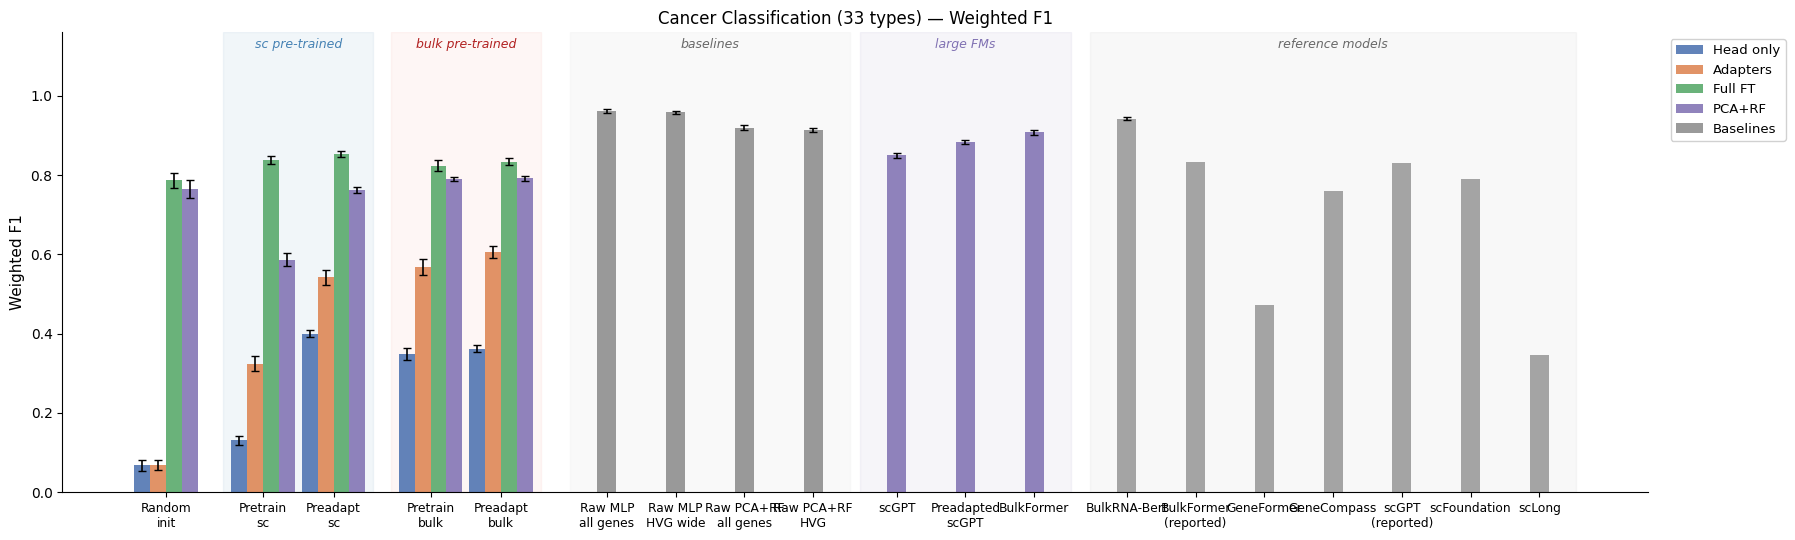

In [407]:
task = "canc_type_class_33"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft", "pca_rf"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT", "pca_rf": "PCA+RF"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868", "pca_rf": "#8172B3"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "f1_weighted_mean"
metric_std = "f1_weighted_std"

baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_pca_rf_all_genes", "Raw PCA+RF\nall genes"),
    ("raw_pca_rf_hvg1199", "Raw PCA+RF\nHVG"),
]
large_fm_specs = [
    ("scgpt_pca_rf", "scGPT"),
    ("scgpt_preadapt_pca_rf", "Preadapted\nscGPT"),
    ("bulkformer_pca_rf", "BulkFormer"),
]

def load_eval_csv(path):
    if os.path.exists(path):
        return pd.read_csv(path, comment="#").set_index("model")
    return None


def load_mode(mode):
    if not head_only_output_is_current(base, task, mode):
        return None
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    df = load_eval_csv(combined)
    if df is not None:
        return df
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None


def load_variant_metrics(specs, metric_col):
    loaded = {}
    for spec in specs:
        canonical = spec[0]
        if canonical in {'scgpt_pca_rf', 'scgpt_preadapt_pca_rf', 'bulkformer_pca_rf'} and not completed_output_is_current(base, task, canonical):
            print(f'Skipping stale or partial external baseline: {canonical}')
            continue
        path = f"{base}/{canonical}/{task}_{canonical}_evaluation_metrics.csv"
        df = load_eval_csv(path)
        if df is not None and metric_col in df.columns:
            loaded[canonical] = df
    return loaded


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = load_variant_metrics(baseline_specs, metric_mean)
large_fm_dfs = load_variant_metrics(large_fm_specs, metric_mean)
available_baselines = [variant for variant, _ in baseline_specs if variant in baseline_dfs]
available_large_fms = [variant for variant, _label in large_fm_specs if variant in large_fm_dfs]
if not available_modes and not available_baselines and not available_large_fms:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.18
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}
baseline_start = 5.0
baseline_spacing = 0.78
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}
large_fm_start = (max(baseline_x.values()) + 0.95) if baseline_x else 5.0
large_fm_spacing = 0.78
large_fm_x = {variant: large_fm_start + i * large_fm_spacing for i, variant in enumerate(available_large_fms)}
rightmost_nonref = max(
    list(baseline_x.values())
    + list(large_fm_x.values())
    + [centers["preadapt_bulk"]]
)
ref_models = [
    ("BulkRNA-Bert", bulkrnabert_weighted_f1_mean, bulkrnabert_weighted_f1_sd),
    ("BulkFormer\n(reported)", bulkformer_weighted_f1_mean, None),
    ("GeneFormer", geneformer_weighted_f1_mean, None),
    ("GeneCompass", genecompass_weighted_f1_mean, None),
    ("scGPT\n(reported)", scgpt_weighted_f1_mean, None),
    ("scFoundation", scfoundation_weighted_f1_mean, None),
    ("scLong", sclong_weighted_f1_mean, None),
]
ref_start = rightmost_nonref + 1.05
ref_spacing = 0.78
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(21, 5.5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    for model, xc in centers.items():
        df = dfs[mode]
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        lbl = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in baseline_dfs:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

for variant, label in large_fm_specs:
    if variant not in large_fm_dfs or variant not in large_fm_x:
        continue
    row = large_fm_dfs[variant].loc["raw_mlp"] if "raw_mlp" in large_fm_dfs[variant].index else large_fm_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(large_fm_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8172B3", alpha=0.88,
           label="_nolegend_",
           error_kw={"linewidth": 1.2})

for x_pos, (_name, mean, sd) in zip(ref_x, ref_models):
    ax.bar(x_pos, mean, bar_w * 1.2, yerr=sd, capsize=3,
           color="#999999", alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2} if sd is not None else {})

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
baseline_lo = (min(baseline_x.values()) - 0.42) if baseline_x else None
baseline_hi = (max(baseline_x.values()) + 0.42) if baseline_x else None
large_fm_lo = (min(large_fm_x.values()) - 0.42) if large_fm_x else None
large_fm_hi = (max(large_fm_x.values()) + 0.42) if large_fm_x else None
ref_lo, ref_hi = ref_x[0] - 0.42, ref_x[-1] + 0.42
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
if baseline_x:
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
if large_fm_x:
    ax.axvspan(large_fm_lo, large_fm_hi, alpha=0.07, color="#8172B3", zorder=0)
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)

y_lim = (0, 1.16)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.015, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.015, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.015, "baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")
if large_fm_x:
    ax.text((large_fm_lo + large_fm_hi) / 2, y_lim[1] - 0.015, "large FMs", ha="center", va="top", fontsize=9, color="#8172B3", style="italic")
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.015, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

large_fm_label_map = {variant: label for variant, label in large_fm_specs}
tick_pos = (
    list(centers.values())
    + list(baseline_x.values())
    + [large_fm_x[v] for v in available_large_fms]
    + ref_x
)
tick_labels = (
    ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"]
    + [dict(baseline_specs)[v] for v in available_baselines]
    + [large_fm_label_map[v] for v in available_large_fms]
    + [name for name, _mean, _sd in ref_models]
)
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.8)
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Cancer Classification (33 types) — Weighted F1", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout(rect=(0, 0, 0.86, 1))
plt.show()


### Bulk pretraining dataset-size downstream comparison

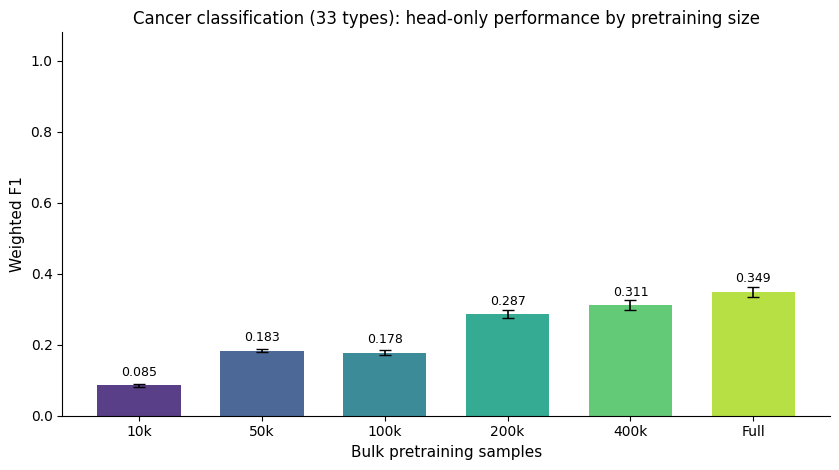

In [408]:
task = "canc_type_class_33"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
metric_mean = "f1_weighted_mean"
metric_std = "f1_weighted_std"

bulk_downstream_specs = [
    ("10k", "head_only_pretrain_bulk_10k"),
    ("50k", "head_only_pretrain_bulk_50k"),
    ("100k", "head_only_pretrain_bulk_100k"),
    ("200k", "head_only_pretrain_bulk_200k"),
    ("400k", "head_only_pretrain_bulk_400k"),
    ("Full", None),
]


def load_bulk_downstream_result(label, variant):
    if label == "Full":
        metadata_path = f"{base}/head_only/{task}_head_only_run_metadata.json"
        candidates = [
            f"{base}/head_only/{task}_head_only_pretrain_bulk_evaluation_metrics.csv",
            f"{base}/head_only/{task}_head_only_evaluation_metrics.csv",
        ]
    else:
        prefix = f"{task}_{variant}"
        metadata_path = f"{base}/{variant}/{prefix}_run_metadata.json"
        candidates = [
            f"{base}/{variant}/{prefix}_evaluation_metrics.csv",
            f"{base}/{variant}/{prefix}_pretrain_bulk_evaluation_metrics.csv",
        ]

    if not os.path.exists(metadata_path):
        return None, None, None
    with open(metadata_path) as handle:
        metadata = __import__("json").load(handle)
    if (
        metadata.get("head_only_backbone_eval") is not True
        or metadata.get("run_status") != "complete"
    ):
        print(f"Skipping incomplete or incompatible head-only result: {label}")
        return None, None, None
    fold_fingerprint = metadata.get("cv_fold_fingerprint")
    if not fold_fingerprint:
        print(f"Skipping head-only result without fold fingerprint: {label}")
        return None, None, None

    for path in candidates:
        if not os.path.exists(path):
            continue
        frame = pd.read_csv(path, comment="#")
        if "model" in frame.columns:
            frame = frame[frame["model"] == "pretrain_bulk"]
        if not frame.empty and metric_mean in frame.columns:
            return frame.iloc[0], path, fold_fingerprint
    return None, None, None


bulk_downstream_rows = []
for label, variant in bulk_downstream_specs:
    row, path, fold_fingerprint = load_bulk_downstream_result(label, variant)
    if row is not None:
        bulk_downstream_rows.append({
            "label": label,
            "mean": float(row[metric_mean]),
            "std": float(row[metric_std]) if metric_std in row.index else 0.0,
            "path": path,
            "fold_fingerprint": fold_fingerprint,
        })

if not bulk_downstream_rows:
    raise FileNotFoundError(f"No complete bulk-size head-only results found under {base}")
if len({row["fold_fingerprint"] for row in bulk_downstream_rows}) != 1:
    raise ValueError("Bulk-size head-only results do not use identical CV folds")

x = np.arange(len(bulk_downstream_rows))
means = np.asarray([row["mean"] for row in bulk_downstream_rows])
stds = np.asarray([row["std"] for row in bulk_downstream_rows])
bar_colors = plt.get_cmap("viridis")(
    np.linspace(0.12, 0.88, len(bulk_downstream_rows))
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    x, means, yerr=stds, capsize=4, width=0.68,
    color=bar_colors, alpha=0.9, error_kw={"linewidth": 1.2},
)
for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2, mean + 0.018, f"{mean:.3f}",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels([row["label"] for row in bulk_downstream_rows])
ax.set_ylim(0, 1.08)
ax.set_xlabel("Bulk pretraining samples", fontsize=11)
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Cancer classification (33 types): head-only performance by pretraining size", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Deconvolution

In [409]:
task = "deconv"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft", "pca_rf"]
mode_labels = {
    "head_only": "Head only", "adapters": "Adapters",
    "full_ft": "Full FT", "pca_rf": "PCA+RF",
}
mode_colors = {
    "head_only": "#4C72B0", "adapters": "#DD8452",
    "full_ft": "#55A868", "pca_rf": "#8172B3",
}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "js_distance_mean"
metric_std = "js_distance_std"
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nMAD 1,199"),
    ("raw_pca_rf_all_genes", "Raw PCA+RF\nall genes"),
    ("raw_pca_rf_hvg1199", "Raw PCA+RF\nMAD 1,199"),
]
large_fm_specs = [
    ("scgpt_pca_rf", "scGPT"),
    ("scgpt_preadapt_pca_rf", "Preadapted\nscGPT"),
    ("bulkformer_pca_rf", "BulkFormer"),
]


def load_deconv_eval(path):
    if os.path.exists(path):
        return pd.read_csv(path, comment="#").set_index("model")
    return None


def deconv_output_is_current(variant):
    metadata_path = f"{base}/{variant}/{task}_{variant}_run_metadata.json"
    if not os.path.exists(metadata_path):
        return False
    with open(metadata_path) as handle:
        metadata = json.load(handle)
    return (
        metadata.get("run_status") == "complete"
        and metadata.get("cv_fold_fingerprint")
        and metadata.get("gene_selection") == "mad"
        and metadata.get("expression_transform") == "log1p"
    )


def load_deconv_mode(mode):
    if not deconv_output_is_current(mode):
        return None
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    frame = load_deconv_eval(combined)
    if frame is not None:
        return frame
    parts = [
        pd.read_csv(
            f"{base}/{mode}/{task}_{mode}_{model}_evaluation_metrics.csv",
            comment="#",
        )
        for model in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{model}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None


def load_deconv_variants(specs, require_complete=False):
    loaded = {}
    for variant, _label in specs:
        if not deconv_output_is_current(variant):
            print(f"Skipping stale or partial external baseline: {variant}")
            continue
        path = f"{base}/{variant}/{task}_{variant}_evaluation_metrics.csv"
        frame = load_deconv_eval(path)
        if frame is not None and metric_mean in frame.columns:
            loaded[variant] = frame
    return loaded


mode_frames = {mode: load_deconv_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if mode_frames[mode] is not None]
baseline_frames = load_deconv_variants(baseline_specs)
large_fm_frames = load_deconv_variants(large_fm_specs, require_complete=True)
available_baselines = [variant for variant, _ in baseline_specs if variant in baseline_frames]
available_large_fms = [variant for variant, _ in large_fm_specs if variant in large_fm_frames]
if not available_modes and not available_baselines and not available_large_fms:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_width = 0.18
centers = {
    "random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9,
    "pretrain_bulk": 3.0, "preadapt_bulk": 3.8,
}
baseline_x = {
    variant: 5.0 + index * 0.78
    for index, variant in enumerate(available_baselines)
}
large_start = max(baseline_x.values(), default=4.05) + 0.95
large_x = {
    variant: large_start + index * 0.78
    for index, variant in enumerate(available_large_fms)
}

mean_baseline_value = None
mean_baseline_std = 0.0
for frame in [*mode_frames.values(), *baseline_frames.values(), *large_fm_frames.values()]:
    if frame is None or "mean_baseline_js_distance_mean" not in frame.columns:
        continue
    mean_baseline_value = float(frame.iloc[0]["mean_baseline_js_distance_mean"])
    if "mean_baseline_js_distance_std" in frame.columns:
        mean_baseline_std = float(frame.iloc[0]["mean_baseline_js_distance_std"])
    break
mean_baseline_x = max([*large_x.values(), *baseline_x.values(), 3.8]) + 0.95

fig, ax = plt.subplots(figsize=(17, 5.5))
added_modes = set()
plotted_values = []
for mode_index, mode in enumerate(available_modes):
    offset = (mode_index - (len(available_modes) - 1) / 2) * bar_width
    frame = mode_frames[mode]
    for model, center in centers.items():
        if model not in frame.index or metric_mean not in frame.columns:
            continue
        mean = float(frame.loc[model, metric_mean])
        std = float(frame.loc[model, metric_std]) if metric_std in frame.columns else 0.0
        ax.bar(
            center + offset, mean, bar_width, yerr=std, capsize=3,
            color=mode_colors[mode], alpha=0.88,
            label=mode_labels[mode] if mode not in added_modes else "",
            error_kw={"linewidth": 1.2},
        )
        plotted_values.append(mean + std)
        added_modes.add(mode)

for variant, _label in baseline_specs:
    if variant not in baseline_frames:
        continue
    row = baseline_frames[variant].iloc[0]
    mean = float(row[metric_mean])
    std = float(row[metric_std]) if metric_std in row.index else 0.0
    ax.bar(
        baseline_x[variant], mean, bar_width * 1.2, yerr=std, capsize=3,
        color="#8C8C8C", alpha=0.88,
        label="Simple baselines" if variant == available_baselines[0] else "",
        error_kw={"linewidth": 1.2},
    )
    plotted_values.append(mean + std)

for variant, _label in large_fm_specs:
    if variant not in large_fm_frames:
        continue
    row = large_fm_frames[variant].iloc[0]
    mean = float(row[metric_mean])
    std = float(row[metric_std]) if metric_std in row.index else 0.0
    ax.bar(
        large_x[variant], mean, bar_width * 1.2, yerr=std, capsize=3,
        color="#8172B3", alpha=0.88, label="_nolegend_",
        error_kw={"linewidth": 1.2},
    )
    plotted_values.append(mean + std)

if mean_baseline_value is not None:
    ax.bar(
        mean_baseline_x, mean_baseline_value, bar_width * 1.2,
        yerr=mean_baseline_std, capsize=3, color="#B0B0B0", alpha=0.88,
        label="_nolegend_", error_kw={"linewidth": 1.2},
    )
    plotted_values.append(mean_baseline_value + mean_baseline_std)

sc_span = (centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45)
bulk_span = (centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45)
ax.axvspan(*sc_span, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(*bulk_span, alpha=0.07, color="salmon", zorder=0)
if baseline_x:
    ax.axvspan(min(baseline_x.values()) - 0.42, max(baseline_x.values()) + 0.42,
               alpha=0.06, color="darkgray", zorder=0)
if large_x:
    ax.axvspan(min(large_x.values()) - 0.42, max(large_x.values()) + 0.42,
               alpha=0.07, color="#8172B3", zorder=0)

y_max = max(plotted_values, default=0.8) * 1.22
ax.set_ylim(0, max(y_max, 0.2))
label_y = ax.get_ylim()[1] * 0.98
ax.text(np.mean(sc_span), label_y, "sc pre-trained", ha="center", va="top",
        fontsize=9, color="steelblue", style="italic")
ax.text(np.mean(bulk_span), label_y, "bulk pre-trained", ha="center", va="top",
        fontsize=9, color="firebrick", style="italic")

label_map = dict([*baseline_specs, *large_fm_specs])
tick_positions = (
    list(centers.values()) + list(baseline_x.values())
    + [large_x[value] for value in available_large_fms]
)
tick_labels = (
    ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"]
    + [label_map[value] for value in available_baselines]
    + [label_map[value] for value in available_large_fms]
)
if mean_baseline_value is not None:
    tick_positions.append(mean_baseline_x)
    tick_labels.append("Training-fold\nmean")
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels, fontsize=8.8)
ax.set_ylabel("Jensen-Shannon distance (lower is better)", fontsize=11)
ax.set_title("Cell-type deconvolution", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=9, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout(rect=(0, 0, 0.86, 1))
plt.show()



Skipping stale or partial external baseline: raw_mlp_all_genes
Skipping stale or partial external baseline: raw_mlp_hvg1199
Skipping stale or partial external baseline: raw_pca_rf_all_genes
Skipping stale or partial external baseline: raw_pca_rf_hvg1199
Skipping stale or partial external baseline: scgpt_pca_rf
Skipping stale or partial external baseline: scgpt_preadapt_pca_rf
Skipping stale or partial external baseline: bulkformer_pca_rf


FileNotFoundError: No evaluation metric files found under /Users/enricoheiss/Thesis/eheiss/output/deconv

### Bulk pretraining dataset-size downstream comparison


In [ ]:
task = "deconv"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
metric_mean = "js_distance_mean"
metric_std = "js_distance_std"
bulk_specs = [
    ("10k", "head_only_pretrain_bulk_10k"),
    ("50k", "head_only_pretrain_bulk_50k"),
    ("100k", "head_only_pretrain_bulk_100k"),
    ("200k", "head_only_pretrain_bulk_200k"),
    ("400k", "head_only_pretrain_bulk_400k"),
    ("Full", None),
]


def load_deconv_bulk_size(label, variant):
    if label == "Full":
        output_dir = "head_only"
        prefix = f"{task}_head_only"
    else:
        output_dir = variant
        prefix = f"{task}_{variant}"
    metadata_path = f"{base}/{output_dir}/{prefix}_run_metadata.json"
    metrics_path = f"{base}/{output_dir}/{prefix}_evaluation_metrics.csv"
    if not os.path.exists(metadata_path) or not os.path.exists(metrics_path):
        return None
    with open(metadata_path) as handle:
        metadata = json.load(handle)
    if (
        metadata.get("head_only_backbone_eval") is not True
        or metadata.get("run_status") != "complete"
        or not metadata.get("cv_fold_fingerprint")
        or metadata.get("gene_selection") != "mad"
        or metadata.get("expression_transform") != "log1p"
    ):
        print(f"Skipping incomplete or incompatible result: {label}")
        return None
    frame = pd.read_csv(metrics_path, comment="#")
    frame = frame[frame["model"] == "pretrain_bulk"]
    if frame.empty or metric_mean not in frame.columns:
        return None
    row = frame.iloc[0]
    return {
        "label": label,
        "mean": float(row[metric_mean]),
        "std": float(row[metric_std]) if metric_std in row.index else 0.0,
        "fold_fingerprint": metadata["cv_fold_fingerprint"],
    }


bulk_rows = [row for label, variant in bulk_specs
             if (row := load_deconv_bulk_size(label, variant)) is not None]
if not bulk_rows:
    raise FileNotFoundError(f"No complete bulk-size head-only results found under {base}")
if len({row["fold_fingerprint"] for row in bulk_rows}) != 1:
    raise ValueError("Bulk-size deconvolution results do not use identical CV folds")

x = np.arange(len(bulk_rows))
means = np.asarray([row["mean"] for row in bulk_rows])
stds = np.asarray([row["std"] for row in bulk_rows])
bar_colors = plt.get_cmap("viridis")(np.linspace(0.12, 0.88, len(bulk_rows)))
fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    x, means, yerr=stds, capsize=4, width=0.68,
    color=bar_colors, alpha=0.9, error_kw={"linewidth": 1.2},
)
offset = max(float(np.max(means + stds)) * 0.025, 0.002)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + offset, f"{mean:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([row["label"] for row in bulk_rows])
ax.set_ylim(0, max(float(np.max(means + stds)) * 1.2, 0.2))
ax.set_xlabel("Bulk pretraining samples", fontsize=11)
ax.set_ylabel("Jensen-Shannon distance (lower is better)", fontsize=11)
ax.set_title("Deconvolution: head-only performance by pretraining size", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()



### Validation-loss convergence


In [ ]:
task = "deconv"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
curve_specs = [
    ("head_only", "Head only", ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]),
    ("adapters", "Adapters", ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]),
    ("full_ft", "Full fine-tuning", ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]),
    ("raw_mlp_all_genes", "Raw MLP, all genes", ["raw_mlp"]),
    ("raw_mlp_hvg1199", "Raw MLP, MAD 1,199", ["raw_mlp"]),
]
model_colors = {
    "random_init": "#4C72B0", "pretrain_sc": "#55A868",
    "preadapt_sc": "#2C7FB8", "pretrain_bulk": "#DD8452",
    "preadapt_bulk": "#C44E52", "raw_mlp": "#666666",
}
available_curve_specs = []
for variant, title, models in curve_specs:
    series = {}
    for model in models:
        path = f"{base}/{variant}/{task}_{variant}_{model}_training_curves.csv"
        if os.path.exists(path):
            frame = pd.read_csv(path)
            if {"epoch", "fold", "validation_loss"}.issubset(frame.columns):
                series[model] = frame
    if series:
        available_curve_specs.append((variant, title, series))
if not available_curve_specs:
    raise FileNotFoundError(f"No deconvolution training curves found under {base}")

n_columns = 2
n_rows = int(np.ceil(len(available_curve_specs) / n_columns))
fig, axes = plt.subplots(n_rows, n_columns, figsize=(12, 4.0 * n_rows), squeeze=False)
for ax, (_variant, title, series) in zip(axes.flat, available_curve_specs):
    for model, frame in series.items():
        summary = frame.groupby("epoch")["validation_loss"].agg(["mean", "std"]).reset_index()
        std = summary["std"].fillna(0.0).to_numpy()
        epochs = summary["epoch"].to_numpy()
        means = summary["mean"].to_numpy()
        ax.plot(epochs, means, marker="o", markersize=3, lw=1.8,
                color=model_colors[model], label=model.replace("_", " "))
        ax.fill_between(epochs, means - std, means + std,
                        color=model_colors[model], alpha=0.12)
    ax.set_yscale("log")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Validation KL loss")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.legend(fontsize=8, framealpha=0.9)
for ax in axes.flat[len(available_curve_specs):]:
    ax.set_visible(False)
fig.suptitle("Deconvolution convergence across folds", fontsize=13)
plt.tight_layout()
plt.show()



## Disease classification

In [ ]:
bulkformer_weighted_f1_mean = 0.939
geneformer_weighted_f1_mean = 0.749
genecompass_weighted_f1_mean = 0.882
scgpt_weighted_f1_mean = 0.885
scfoundation_weighted_f1_mean = 0.874
sclong_weighted_f1_mean = 0.81


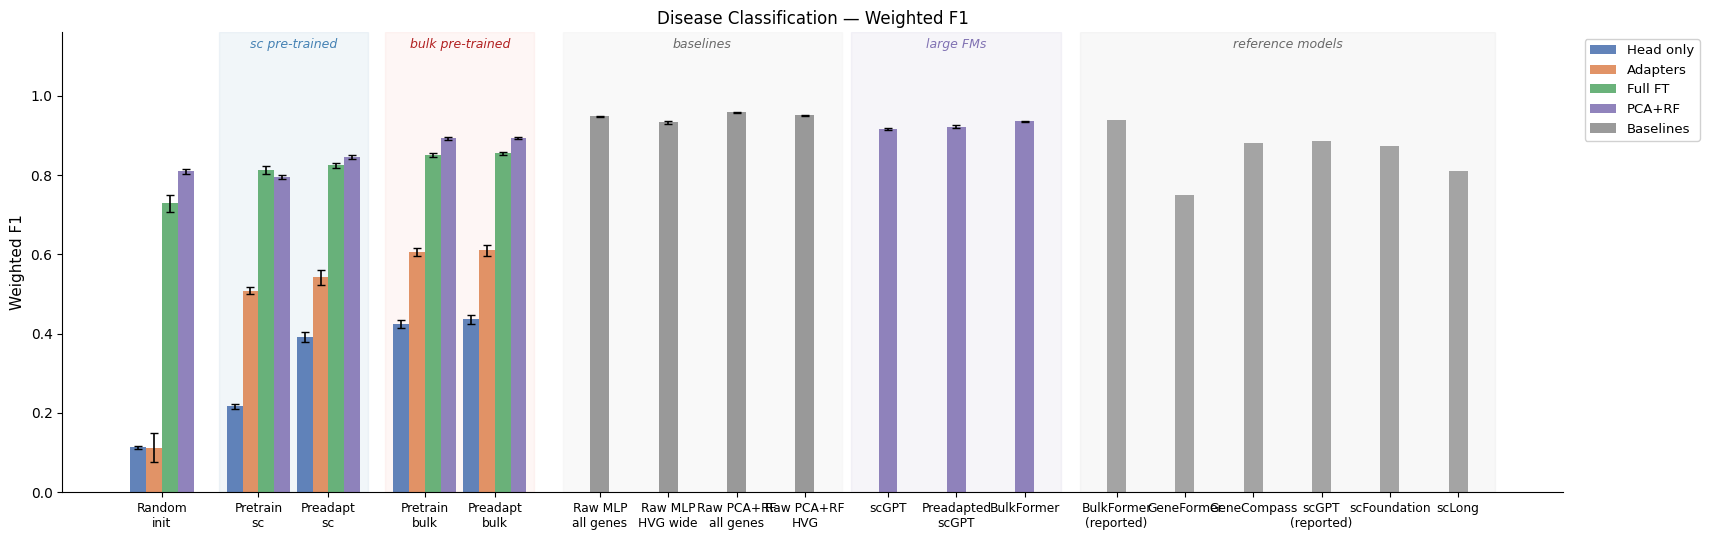

In [ ]:
task = "disease_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft", "pca_rf"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT", "pca_rf": "PCA+RF"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868", "pca_rf": "#8172B3"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "f1_weighted_mean"
metric_std = "f1_weighted_std"

baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_pca_rf_all_genes", "Raw PCA+RF\nall genes"),
    ("raw_pca_rf_hvg1199", "Raw PCA+RF\nHVG"),
]
large_fm_specs = [
    ("scgpt_pca_rf", "scGPT"),
    ("scgpt_preadapt_pca_rf", "Preadapted\nscGPT"),
    ("bulkformer_pca_rf", "BulkFormer"),
]

def load_eval_csv(path):
    if os.path.exists(path):
        return pd.read_csv(path, comment="#").set_index("model")
    return None


def load_mode(mode):
    if not head_only_output_is_current(base, task, mode):
        return None
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    df = load_eval_csv(combined)
    if df is not None:
        return df
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None


def load_variant_metrics(specs, metric_col):
    loaded = {}
    for spec in specs:
        canonical = spec[0]
        if canonical in {'scgpt_pca_rf', 'scgpt_preadapt_pca_rf', 'bulkformer_pca_rf'} and not completed_output_is_current(base, task, canonical):
            print(f'Skipping stale or partial external baseline: {canonical}')
            continue
        path = f"{base}/{canonical}/{task}_{canonical}_evaluation_metrics.csv"
        df = load_eval_csv(path)
        if df is not None and metric_col in df.columns:
            loaded[canonical] = df
    return loaded


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = load_variant_metrics(baseline_specs, metric_mean)
large_fm_dfs = load_variant_metrics(large_fm_specs, metric_mean)
available_baselines = [variant for variant, _ in baseline_specs if variant in baseline_dfs]
available_large_fms = [variant for variant, _label in large_fm_specs if variant in large_fm_dfs]
if not available_modes and not available_baselines and not available_large_fms:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.18
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}
baseline_start = 5.0
baseline_spacing = 0.78
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}
large_fm_start = (max(baseline_x.values()) + 0.95) if baseline_x else 5.0
large_fm_spacing = 0.78
large_fm_x = {variant: large_fm_start + i * large_fm_spacing for i, variant in enumerate(available_large_fms)}
rightmost_nonref = max(
    list(baseline_x.values())
    + list(large_fm_x.values())
    + [centers["preadapt_bulk"]]
)
ref_models = [
    ("BulkFormer\n(reported)", bulkformer_weighted_f1_mean, None),
    ("GeneFormer", geneformer_weighted_f1_mean, None),
    ("GeneCompass", genecompass_weighted_f1_mean, None),
    ("scGPT\n(reported)", scgpt_weighted_f1_mean, None),
    ("scFoundation", scfoundation_weighted_f1_mean, None),
    ("scLong", sclong_weighted_f1_mean, None),
]
ref_start = rightmost_nonref + 1.05
ref_spacing = 0.78
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(20, 5.5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    for model, xc in centers.items():
        df = dfs[mode]
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        lbl = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in baseline_dfs:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

for variant, label in large_fm_specs:
    if variant not in large_fm_dfs or variant not in large_fm_x:
        continue
    row = large_fm_dfs[variant].loc["raw_mlp"] if "raw_mlp" in large_fm_dfs[variant].index else large_fm_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(large_fm_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8172B3", alpha=0.88,
           label="_nolegend_",
           error_kw={"linewidth": 1.2})

for x_pos, (_name, mean, sd) in zip(ref_x, ref_models):
    ax.bar(x_pos, mean, bar_w * 1.2, yerr=sd, capsize=3,
           color="#999999", alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2} if sd is not None else {})

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
baseline_lo = (min(baseline_x.values()) - 0.42) if baseline_x else None
baseline_hi = (max(baseline_x.values()) + 0.42) if baseline_x else None
large_fm_lo = (min(large_fm_x.values()) - 0.42) if large_fm_x else None
large_fm_hi = (max(large_fm_x.values()) + 0.42) if large_fm_x else None
ref_lo, ref_hi = ref_x[0] - 0.42, ref_x[-1] + 0.42
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
if baseline_x:
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
if large_fm_x:
    ax.axvspan(large_fm_lo, large_fm_hi, alpha=0.07, color="#8172B3", zorder=0)
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)

y_lim = (0, 1.16)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.015, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.015, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.015, "baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")
if large_fm_x:
    ax.text((large_fm_lo + large_fm_hi) / 2, y_lim[1] - 0.015, "large FMs", ha="center", va="top", fontsize=9, color="#8172B3", style="italic")
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.015, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

large_fm_label_map = {variant: label for variant, label in large_fm_specs}
tick_pos = (
    list(centers.values())
    + list(baseline_x.values())
    + [large_fm_x[v] for v in available_large_fms]
    + ref_x
)
tick_labels = (
    ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"]
    + [dict(baseline_specs)[v] for v in available_baselines]
    + [large_fm_label_map[v] for v in available_large_fms]
    + [name for name, _mean, _sd in ref_models]
)
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.8)
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Disease Classification — Weighted F1", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout(rect=(0, 0, 0.86, 1))
plt.show()


### Bulk pretraining dataset-size downstream comparison

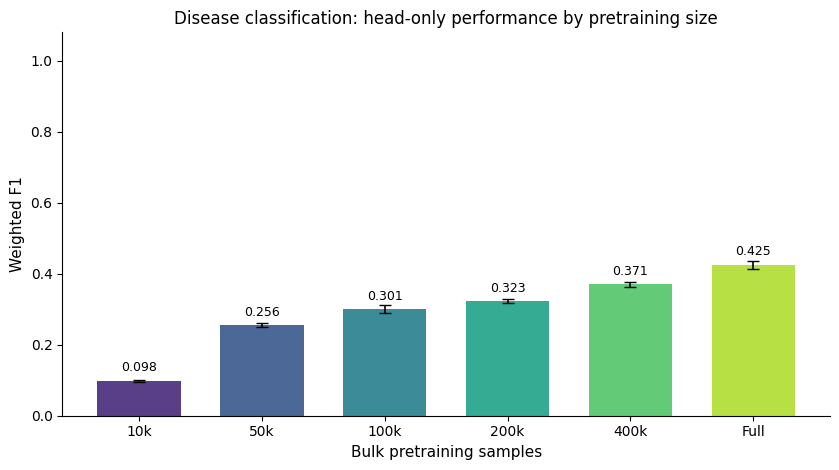

In [ ]:
task = "disease_class"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
metric_mean = "f1_weighted_mean"
metric_std = "f1_weighted_std"

bulk_downstream_specs = [
    ("10k", "head_only_pretrain_bulk_10k"),
    ("50k", "head_only_pretrain_bulk_50k"),
    ("100k", "head_only_pretrain_bulk_100k"),
    ("200k", "head_only_pretrain_bulk_200k"),
    ("400k", "head_only_pretrain_bulk_400k"),
    ("Full", None),
]


def load_bulk_downstream_result(label, variant):
    if label == "Full":
        metadata_path = f"{base}/head_only/{task}_head_only_run_metadata.json"
        candidates = [
            f"{base}/head_only/{task}_head_only_pretrain_bulk_evaluation_metrics.csv",
            f"{base}/head_only/{task}_head_only_evaluation_metrics.csv",
        ]
    else:
        prefix = f"{task}_{variant}"
        metadata_path = f"{base}/{variant}/{prefix}_run_metadata.json"
        candidates = [
            f"{base}/{variant}/{prefix}_evaluation_metrics.csv",
            f"{base}/{variant}/{prefix}_pretrain_bulk_evaluation_metrics.csv",
        ]

    if not os.path.exists(metadata_path):
        return None, None, None
    with open(metadata_path) as handle:
        metadata = __import__("json").load(handle)
    if (
        metadata.get("head_only_backbone_eval") is not True
        or metadata.get("run_status") != "complete"
    ):
        print(f"Skipping incomplete or incompatible head-only result: {label}")
        return None, None, None
    fold_fingerprint = metadata.get("cv_fold_fingerprint")
    if not fold_fingerprint:
        print(f"Skipping head-only result without fold fingerprint: {label}")
        return None, None, None

    for path in candidates:
        if not os.path.exists(path):
            continue
        frame = pd.read_csv(path, comment="#")
        if "model" in frame.columns:
            frame = frame[frame["model"] == "pretrain_bulk"]
        if not frame.empty and metric_mean in frame.columns:
            return frame.iloc[0], path, fold_fingerprint
    return None, None, None


bulk_downstream_rows = []
for label, variant in bulk_downstream_specs:
    row, path, fold_fingerprint = load_bulk_downstream_result(label, variant)
    if row is not None:
        bulk_downstream_rows.append({
            "label": label,
            "mean": float(row[metric_mean]),
            "std": float(row[metric_std]) if metric_std in row.index else 0.0,
            "path": path,
            "fold_fingerprint": fold_fingerprint,
        })

if not bulk_downstream_rows:
    raise FileNotFoundError(f"No complete bulk-size head-only results found under {base}")
if len({row["fold_fingerprint"] for row in bulk_downstream_rows}) != 1:
    raise ValueError("Bulk-size head-only results do not use identical CV folds")

x = np.arange(len(bulk_downstream_rows))
means = np.asarray([row["mean"] for row in bulk_downstream_rows])
stds = np.asarray([row["std"] for row in bulk_downstream_rows])
bar_colors = plt.get_cmap("viridis")(
    np.linspace(0.12, 0.88, len(bulk_downstream_rows))
)

fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    x, means, yerr=stds, capsize=4, width=0.68,
    color=bar_colors, alpha=0.9, error_kw={"linewidth": 1.2},
)
for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width() / 2, mean + 0.018, f"{mean:.3f}",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_xticks(x)
ax.set_xticklabels([row["label"] for row in bulk_downstream_rows])
ax.set_ylim(0, 1.08)
ax.set_xlabel("Bulk pretraining samples", fontsize=11)
ax.set_ylabel("Weighted F1", fontsize=11)
ax.set_title("Disease classification: head-only performance by pretraining size", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Drug response prediction

In [ ]:
bulkformer_pcc_mean = 0.91
geneformer_pcc_mean = 0.873
genecompass_pcc_mean = 0.872
scgpt_pcc_mean = 0.877
scfoundation_pcc_mean = 0.88
sclong_pcc_mean = 0.843


Skipping incomplete or incompatible output for drug_resp/adapters
Skipping incomplete or incompatible output for drug_resp/full_ft


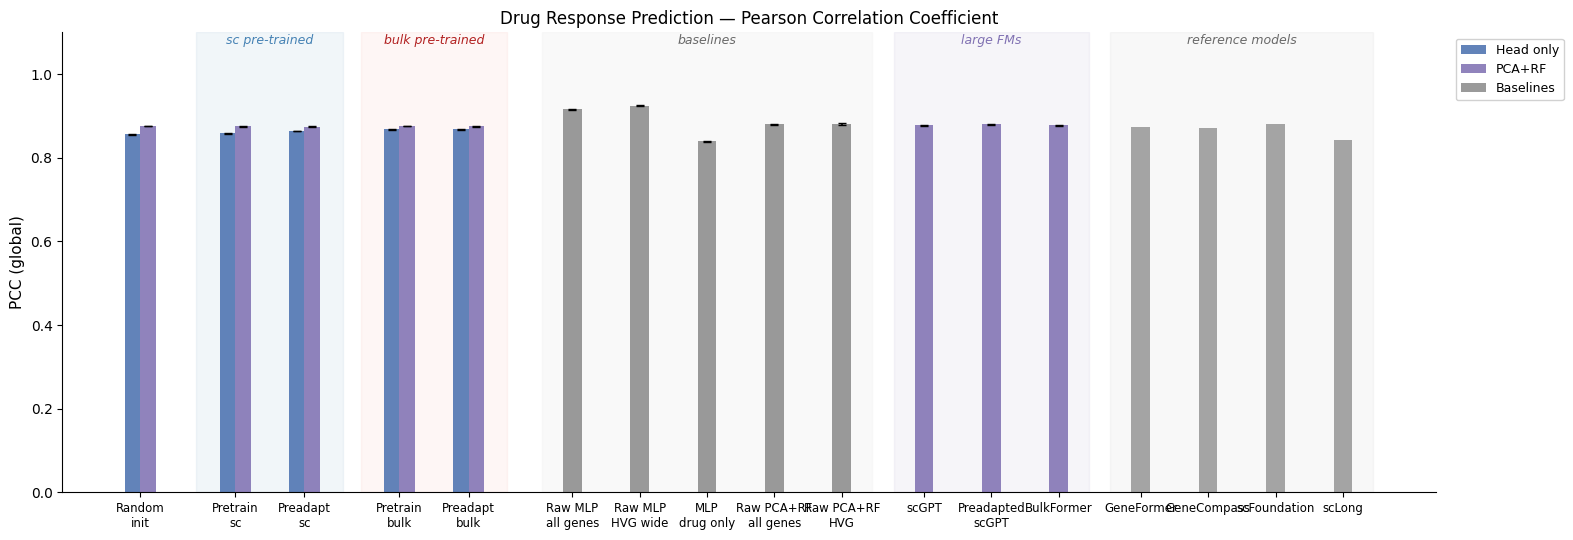

In [ ]:
task = "drug_resp"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft", "pca_rf"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT", "pca_rf": "PCA+RF"}
colors = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868", "pca_rf": "#8172B3"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "global_pcc_mean"
metric_std = "global_pcc_std"
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nHVG wide"),
    ("raw_mlp_drug_only", "MLP\ndrug only"),
    ("raw_pca_rf_all_genes", "Raw PCA+RF\nall genes"),
    ("raw_pca_rf_hvg1199", "Raw PCA+RF\nHVG"),
]
large_fm_specs = [
    ("scgpt_pca_rf", "scGPT"),
    ("scgpt_preadapt_pca_rf", "Preadapted\nscGPT"),
    ("bulkformer_pca_rf", "BulkFormer"),
]


def load_mode(mode):
    if mode == "pca_rf" and not completed_output_is_current(base, task, mode):
        print("Skipping stale or partial scbFM PCA+RF output")
        return None
    if not head_only_output_is_current(base, task, mode):
        return None
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    if os.path.exists(combined):
        return pd.read_csv(combined, comment="#").set_index("model")
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None




def load_variants(specs, require_complete=False):
    loaded = {}
    for variant, _ in specs:
        if require_complete and not completed_output_is_current(base, task, variant):
            print(f"Skipping stale or partial variant: {variant}")
            continue
        path = f"{base}/{variant}/{task}_{variant}_evaluation_metrics.csv"
        if os.path.exists(path):
            df = pd.read_csv(path, comment="#").set_index("model")
            if metric_mean in df.columns:
                loaded[variant] = df
    return loaded


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = load_variants(baseline_specs, require_complete=True)
large_fm_dfs = load_variants(large_fm_specs, require_complete=True)
available_baselines = [variant for variant, _ in baseline_specs if variant in baseline_dfs]
available_large_fms = [variant for variant, _ in large_fm_specs if variant in large_fm_dfs]
if not available_modes and not available_baselines and not available_large_fms:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.18
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_start = 5.0
baseline_spacing = 0.78
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}
large_fm_start = (max(baseline_x.values()) + 0.95) if baseline_x else 5.0
large_fm_spacing = 0.78
large_fm_x = {variant: large_fm_start + i * large_fm_spacing for i, variant in enumerate(available_large_fms)}

ref_models = [
    ("GeneFormer",   geneformer_pcc_mean,   None),
    ("GeneCompass",  genecompass_pcc_mean,  None),
    ("scFoundation", scfoundation_pcc_mean, None),
    ("scLong",       sclong_pcc_mean,        None),
]
nonref_x = list(baseline_x.values()) + list(large_fm_x.values()) + [centers["preadapt_bulk"]]
ref_start = max(nonref_x) + 0.95
ref_spacing = 0.78
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(18, 5.5))
added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    df = dfs[mode]
    for model, xc in centers.items():
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        label = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode], capsize=3,
               alpha=0.88, label=label, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in available_baselines:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

for variant, label in large_fm_specs:
    if variant not in large_fm_dfs:
        continue
    row = large_fm_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(large_fm_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8172B3", alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2})

for i, (name, mean, sd) in enumerate(ref_models):
    ax.bar(ref_x[i], mean, bar_w * 1.2, yerr=sd, color="#999999",
           capsize=3, alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2} if sd else {})

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
y_lim = (0, 1.1)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.003, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.003, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    baseline_lo, baseline_hi = min(baseline_x.values()) - 0.35, max(baseline_x.values()) + 0.35
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.003, "baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

if large_fm_x:
    large_fm_lo, large_fm_hi = min(large_fm_x.values()) - 0.35, max(large_fm_x.values()) + 0.35
    ax.axvspan(large_fm_lo, large_fm_hi, alpha=0.07, color="#8172B3", zorder=0)
    ax.text((large_fm_lo + large_fm_hi) / 2, y_lim[1] - 0.003, "large FMs", ha="center", va="top", fontsize=9, color="#8172B3", style="italic")

ref_lo, ref_hi = ref_x[0] - 0.35, ref_x[-1] + 0.35
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.003, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

large_fm_labels = dict(large_fm_specs)
tick_pos = list(centers.values()) + list(baseline_x.values()) + [large_fm_x[v] for v in available_large_fms] + ref_x
tick_labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [dict(baseline_specs)[v] for v in available_baselines] + [large_fm_labels[v] for v in available_large_fms] + [n for n, _, _ in ref_models]
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.5)
ax.set_ylabel("PCC (global)", fontsize=11)
ax.set_title("Drug Response Prediction — Pearson Correlation Coefficient", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=9, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout(rect=(0, 0, 0.88, 1))
plt.show()


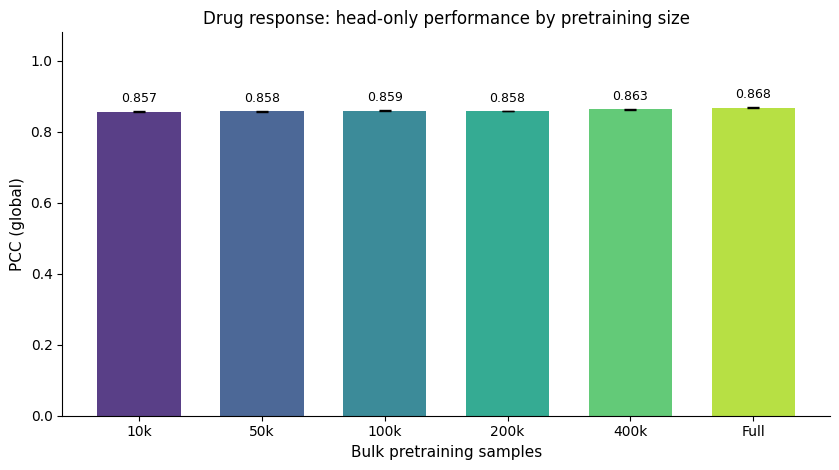

In [ ]:
task = "drug_resp"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
metric_mean = "global_pcc_mean"
metric_std = "global_pcc_std"
bulk_downstream_specs = [
    ("10k", "head_only_pretrain_bulk_10k"),
    ("50k", "head_only_pretrain_bulk_50k"),
    ("100k", "head_only_pretrain_bulk_100k"),
    ("200k", "head_only_pretrain_bulk_200k"),
    ("400k", "head_only_pretrain_bulk_400k"),
    ("Full", None),
]


def load_drug_bulk_size_result(label, variant):
    if label == "Full":
        metadata_path = f"{base}/head_only/{task}_head_only_run_metadata.json"
        candidates = [
            f"{base}/head_only/{task}_head_only_pretrain_bulk_evaluation_metrics.csv",
            f"{base}/head_only/{task}_head_only_evaluation_metrics.csv",
        ]
    else:
        prefix = f"{task}_{variant}"
        metadata_path = f"{base}/{variant}/{prefix}_run_metadata.json"
        candidates = [
            f"{base}/{variant}/{prefix}_evaluation_metrics.csv",
            f"{base}/{variant}/{prefix}_pretrain_bulk_evaluation_metrics.csv",
        ]
    if not os.path.exists(metadata_path):
        return None, None
    with open(metadata_path) as handle:
        metadata = json.load(handle)
    if metadata.get("head_only_backbone_eval") is not True or metadata.get("run_status") != "complete":
        print(f"Skipping incomplete or incompatible head-only result: {label}")
        return None, None
    fingerprint = metadata.get("cv_fold_fingerprint")
    if not fingerprint:
        print(f"Skipping result without fold fingerprint: {label}")
        return None, None
    for path in candidates:
        if not os.path.exists(path):
            continue
        frame = pd.read_csv(path, comment="#")
        if "model" in frame.columns:
            frame = frame[frame["model"] == "pretrain_bulk"]
        if not frame.empty and metric_mean in frame.columns:
            return frame.iloc[0], fingerprint
    return None, None


bulk_size_rows = []
for label, variant in bulk_downstream_specs:
    row, fingerprint = load_drug_bulk_size_result(label, variant)
    if row is not None:
        bulk_size_rows.append({
            "label": label,
            "mean": float(row[metric_mean]),
            "std": float(row[metric_std]) if metric_std in row.index else 0.0,
            "fold_fingerprint": fingerprint,
        })
if not bulk_size_rows:
    raise FileNotFoundError(f"No complete drug-response bulk-size results found under {base}")
if len({row["fold_fingerprint"] for row in bulk_size_rows}) != 1:
    raise ValueError("Drug-response bulk-size results do not use identical CV folds")

x = np.arange(len(bulk_size_rows))
means = np.asarray([row["mean"] for row in bulk_size_rows])
stds = np.asarray([row["std"] for row in bulk_size_rows])
bar_colors = plt.get_cmap("viridis")(np.linspace(0.12, 0.88, len(bulk_size_rows)))
fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(x, means, yerr=stds, capsize=4, width=0.68, color=bar_colors, alpha=0.9, error_kw={"linewidth": 1.2})
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.018, f"{mean:.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([row["label"] for row in bulk_size_rows])
ax.set_ylim(0, 1.08)
ax.set_xlabel("Bulk pretraining samples", fontsize=11)
ax.set_ylabel("PCC (global)", fontsize=11)
ax.set_title("Drug response: head-only performance by pretraining size", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()


## Gene essentiality prediction

In [ ]:
bulkformer_pcc_mean = 0.931
geneformer_pcc_mean = 0.897
genecompass_pcc_mean = 0.881
scgpt_pcc_mean = 0.907
scfoundation_pcc_mean = 0.852
sclong_pcc_mean = 0.889


Skipping stale or partial baseline: scgpt_pca_rf
Skipping stale or partial baseline: bulkformer_pca_rf


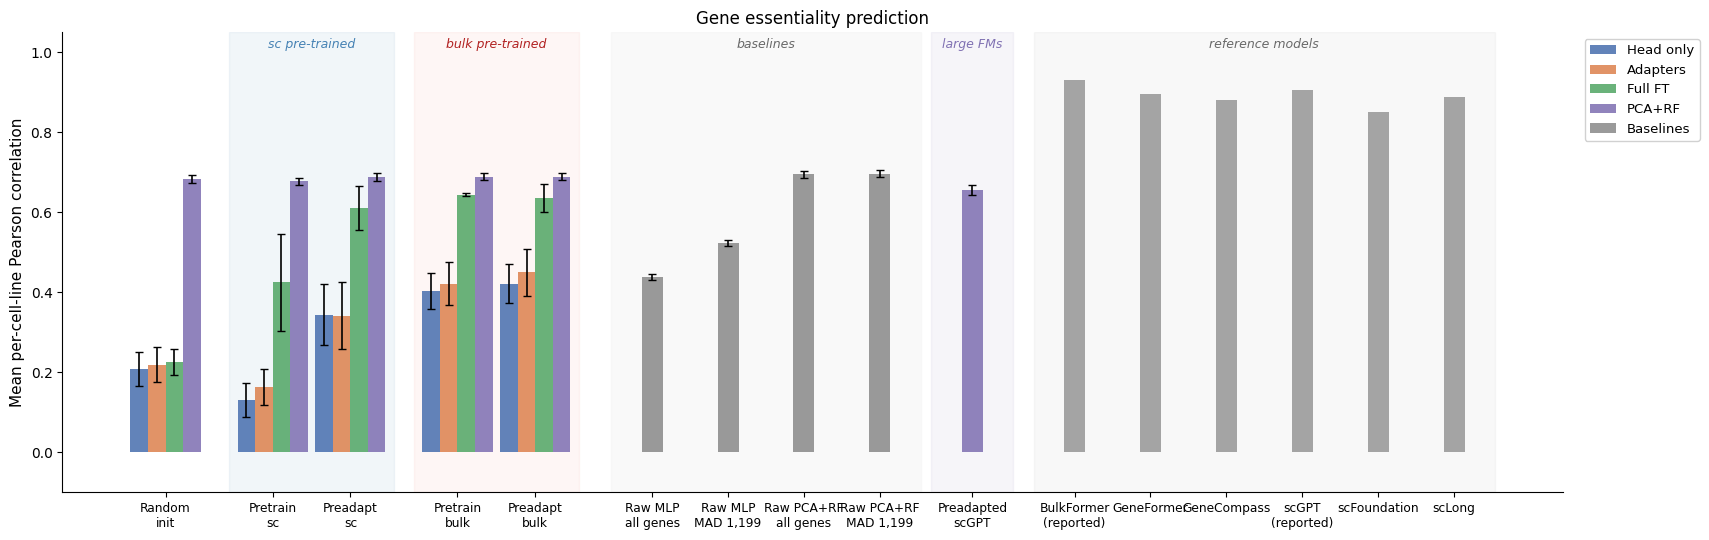

In [ ]:
task = "gene_essent"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
modes = ["head_only", "adapters", "full_ft", "pca_rf"]
mode_labels = {"head_only": "Head only", "adapters": "Adapters", "full_ft": "Full FT", "pca_rf": "PCA+RF"}
colors  = {"head_only": "#4C72B0", "adapters": "#DD8452", "full_ft": "#55A868", "pca_rf": "#8172B3"}
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
metric_mean = "test_pcc_mean"
metric_std = "test_pcc_std"

baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nMAD 1,199"),
    ("raw_pca_rf_all_genes", "Raw PCA+RF\nall genes"),
    ("raw_pca_rf_hvg1199", "Raw PCA+RF\nMAD 1,199"),
]
large_fm_specs = [
    ("scgpt_pca_rf", "scGPT"),
    ("scgpt_preadapt_pca_rf", "Preadapted\nscGPT"),
    ("bulkformer_pca_rf", "BulkFormer"),
]

def load_eval_csv(path):
    if os.path.exists(path):
        return pd.read_csv(path, comment="#").set_index("model")
    return None


def load_mode(mode):
    if mode == "pca_rf" and not completed_output_is_current(base, task, mode):
        return None
    if not head_only_output_is_current(base, task, mode):
        return None
    combined = f"{base}/{mode}/{task}_{mode}_evaluation_metrics.csv"
    df = load_eval_csv(combined)
    if df is not None:
        return df
    parts = [
        pd.read_csv(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv", comment="#")
        for m in model_keys
        if os.path.exists(f"{base}/{mode}/{task}_{mode}_{m}_evaluation_metrics.csv")
    ]
    return pd.concat(parts).set_index("model") if parts else None


def load_variant_metrics(specs, metric_col):
    loaded = {}
    for spec in specs:
        canonical = spec[0]
        if not completed_output_is_current(base, task, canonical):
            print(f'Skipping stale or partial baseline: {canonical}')
            continue
        path = f"{base}/{canonical}/{task}_{canonical}_evaluation_metrics.csv"
        df = load_eval_csv(path)
        if df is not None and metric_col in df.columns:
            loaded[canonical] = df
    return loaded


dfs = {mode: load_mode(mode) for mode in modes}
available_modes = [mode for mode in modes if dfs[mode] is not None]
baseline_dfs = load_variant_metrics(baseline_specs, metric_mean)
large_fm_dfs = load_variant_metrics(large_fm_specs, metric_mean)
available_baselines = [variant for variant, _ in baseline_specs if variant in baseline_dfs]
available_large_fms = [variant for variant, _label in large_fm_specs if variant in large_fm_dfs]
if not available_modes and not available_baselines and not available_large_fms:
    raise FileNotFoundError(f"No evaluation metric files found under {base}")

bar_w = 0.18
centers = {
    "random_init":  0.0,
    "pretrain_sc":  1.1,
    "preadapt_sc":  1.9,
    "pretrain_bulk": 3.0,
    "preadapt_bulk": 3.8,
}
baseline_start = 5.0
baseline_spacing = 0.78
baseline_x = {variant: baseline_start + i * baseline_spacing for i, variant in enumerate(available_baselines)}
large_fm_start = (max(baseline_x.values()) + 0.95) if baseline_x else 5.0
large_fm_spacing = 0.78
large_fm_x = {variant: large_fm_start + i * large_fm_spacing for i, variant in enumerate(available_large_fms)}
rightmost_nonref = max(
    list(baseline_x.values())
    + list(large_fm_x.values())
    + [centers["preadapt_bulk"]]
)
ref_models = [
    ("BulkFormer\n(reported)", bulkformer_pcc_mean, None),
    ("GeneFormer", geneformer_pcc_mean, None),
    ("GeneCompass", genecompass_pcc_mean, None),
    ("scGPT\n(reported)", scgpt_pcc_mean, None),
    ("scFoundation", scfoundation_pcc_mean, None),
    ("scLong", sclong_pcc_mean, None),
]
ref_start = rightmost_nonref + 1.05
ref_spacing = 0.78
ref_x = [ref_start + i * ref_spacing for i in range(len(ref_models))]

fig, ax = plt.subplots(figsize=(20, 5.5))

added = set()
for m_idx, mode in enumerate(available_modes):
    offset = (m_idx - (len(available_modes) - 1) / 2) * bar_w
    for model, xc in centers.items():
        df = dfs[mode]
        if df is None or model not in df.index or metric_mean not in df.columns:
            continue
        mean = df.loc[model, metric_mean]
        std = df.loc[model, metric_std] if metric_std in df.columns else 0.0
        lbl = mode_labels[mode] if mode not in added else ""
        ax.bar(xc + offset, mean, bar_w, yerr=std, color=colors[mode],
               capsize=3, alpha=0.88, label=lbl, error_kw={"linewidth": 1.2})
        added.add(mode)

for variant, label in baseline_specs:
    if variant not in baseline_dfs:
        continue
    row = baseline_dfs[variant].loc["raw_mlp"] if "raw_mlp" in baseline_dfs[variant].index else baseline_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(baseline_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8C8C8C", alpha=0.88,
           label="Baselines" if variant == available_baselines[0] else "",
           error_kw={"linewidth": 1.2})

for variant, label in large_fm_specs:
    if variant not in large_fm_dfs or variant not in large_fm_x:
        continue
    row = large_fm_dfs[variant].loc["raw_mlp"] if "raw_mlp" in large_fm_dfs[variant].index else large_fm_dfs[variant].iloc[0]
    mean = row[metric_mean]
    std = row[metric_std] if metric_std in row.index else 0.0
    ax.bar(large_fm_x[variant], mean, bar_w * 1.2, yerr=std, capsize=3,
           color="#8172B3", alpha=0.88,
           label="_nolegend_",
           error_kw={"linewidth": 1.2})

for x_pos, (_name, mean, sd) in zip(ref_x, ref_models):
    ax.bar(x_pos, mean, bar_w * 1.2, yerr=sd, capsize=3,
           color="#999999", alpha=0.88, label="_nolegend_",
           error_kw={"linewidth": 1.2} if sd is not None else {})

sc_lo, sc_hi = centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45
bulk_lo, bulk_hi = centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45
baseline_lo = (min(baseline_x.values()) - 0.42) if baseline_x else None
baseline_hi = (max(baseline_x.values()) + 0.42) if baseline_x else None
large_fm_lo = (min(large_fm_x.values()) - 0.42) if large_fm_x else None
large_fm_hi = (max(large_fm_x.values()) + 0.42) if large_fm_x else None
ref_lo, ref_hi = ref_x[0] - 0.42, ref_x[-1] + 0.42
ax.axvspan(sc_lo, sc_hi, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(bulk_lo, bulk_hi, alpha=0.07, color="salmon", zorder=0)
if baseline_x:
    ax.axvspan(baseline_lo, baseline_hi, alpha=0.06, color="darkgray", zorder=0)
if large_fm_x:
    ax.axvspan(large_fm_lo, large_fm_hi, alpha=0.07, color="#8172B3", zorder=0)
ax.axvspan(ref_lo, ref_hi, alpha=0.05, color="gray", zorder=0)

y_lim = (-0.1, 1.05)
ax.set_ylim(*y_lim)
ax.text((sc_lo + sc_hi) / 2, y_lim[1] - 0.015, "sc pre-trained", ha="center", va="top", fontsize=9, color="steelblue", style="italic")
ax.text((bulk_lo + bulk_hi) / 2, y_lim[1] - 0.015, "bulk pre-trained", ha="center", va="top", fontsize=9, color="firebrick", style="italic")
if baseline_x:
    ax.text((baseline_lo + baseline_hi) / 2, y_lim[1] - 0.015, "baselines", ha="center", va="top", fontsize=9, color="dimgray", style="italic")
if large_fm_x:
    ax.text((large_fm_lo + large_fm_hi) / 2, y_lim[1] - 0.015, "large FMs", ha="center", va="top", fontsize=9, color="#8172B3", style="italic")
ax.text((ref_lo + ref_hi) / 2, y_lim[1] - 0.015, "reference models", ha="center", va="top", fontsize=9, color="dimgray", style="italic")

large_fm_label_map = {variant: label for variant, label in large_fm_specs}
tick_pos = (
    list(centers.values())
    + list(baseline_x.values())
    + [large_fm_x[v] for v in available_large_fms]
    + ref_x
)
tick_labels = (
    ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"]
    + [dict(baseline_specs)[v] for v in available_baselines]
    + [large_fm_label_map[v] for v in available_large_fms]
    + [name for name, _mean, _sd in ref_models]
)
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels, fontsize=8.8)
ax.set_ylabel("Mean per-cell-line Pearson correlation", fontsize=11)
ax.set_title("Gene essentiality prediction", fontsize=12)
ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=9.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout(rect=(0, 0, 0.86, 1))
plt.show()


### Bulk pretraining dataset-size downstream comparison


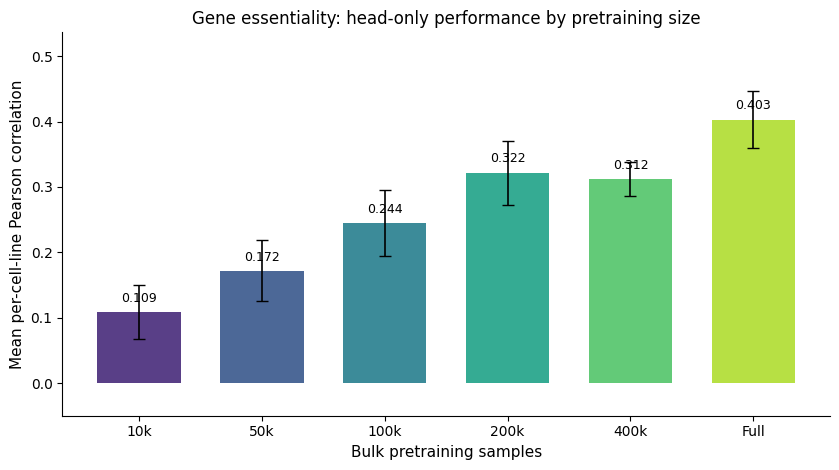

In [ ]:
task = "gene_essent"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
metric_mean = "test_pcc_mean"
metric_std = "test_pcc_std"
bulk_specs = [
    ("10k", "head_only_pretrain_bulk_10k"),
    ("50k", "head_only_pretrain_bulk_50k"),
    ("100k", "head_only_pretrain_bulk_100k"),
    ("200k", "head_only_pretrain_bulk_200k"),
    ("400k", "head_only_pretrain_bulk_400k"),
    ("Full", None),
]


def load_gene_essent_bulk_size(label, variant):
    if label == "Full":
        output_dir = "head_only"
        prefix = f"{task}_head_only"
    else:
        output_dir = variant
        prefix = f"{task}_{variant}"
    metadata_path = f"{base}/{output_dir}/{prefix}_run_metadata.json"
    metrics_path = f"{base}/{output_dir}/{prefix}_evaluation_metrics.csv"
    if not os.path.exists(metadata_path) or not os.path.exists(metrics_path):
        return None
    with open(metadata_path) as handle:
        metadata = json.load(handle)
    if (
        metadata.get("head_only_backbone_eval") is not True
        or metadata.get("run_status") != "complete"
        or not metadata.get("cv_fold_fingerprint")
        or metadata.get("gene_selection_method") != "mad"
    ):
        print(f"Skipping incomplete or incompatible result: {label}")
        return None
    frame = pd.read_csv(metrics_path, comment="#")
    frame = frame[frame["model"] == "pretrain_bulk"]
    if frame.empty or metric_mean not in frame.columns:
        return None
    row = frame.iloc[0]
    return {
        "label": label,
        "mean": float(row[metric_mean]),
        "std": float(row[metric_std]) if metric_std in row.index else 0.0,
        "fold_fingerprint": metadata["cv_fold_fingerprint"],
    }


bulk_rows = [row for label, variant in bulk_specs
             if (row := load_gene_essent_bulk_size(label, variant)) is not None]
if not bulk_rows:
    raise FileNotFoundError(f"No complete bulk-size head-only results found under {base}")
if len({row["fold_fingerprint"] for row in bulk_rows}) != 1:
    raise ValueError("Bulk-size gene-essentiality results do not use identical CV folds")

x = np.arange(len(bulk_rows))
means = np.asarray([row["mean"] for row in bulk_rows])
stds = np.asarray([row["std"] for row in bulk_rows])
bar_colors = plt.get_cmap("viridis")(np.linspace(0.12, 0.88, len(bulk_rows)))
fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.bar(
    x, means, yerr=stds, capsize=4, width=0.68,
    color=bar_colors, alpha=0.9, error_kw={"linewidth": 1.2},
)
offset = max(float(np.max(means + stds)) * 0.025, 0.002)
for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, mean + offset, f"{mean:.3f}",
            ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels([row["label"] for row in bulk_rows])
ax.set_ylim(min(-0.05, float(np.min(means - stds)) * 1.15), max(float(np.max(means + stds)) * 1.2, 0.2))
ax.set_xlabel("Bulk pretraining samples", fontsize=11)
ax.set_ylabel("Mean per-cell-line Pearson correlation", fontsize=11)
ax.set_title("Gene essentiality: head-only performance by pretraining size", fontsize=12)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()



## Survival prediction

In [ ]:
bulkrnabert_weighted_c_mean = 0.621
bulkrnabert_weighted_c_sd = 0.015


In [ ]:
task = "surv_pred"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
metric_mean, metric_std = "test_cohort_weighted_c_index_mean", "test_cohort_weighted_c_index_std"
nested_by_cancer = False
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
mode_specs = [
    ("head_only", "Head only", "#4C72B0"),
    ("adapters", "Adapters", "#DD8452"),
    ("full_ft", "Full FT", "#55A868"),
    ("pca_rf", "PCA+RF", "#8172B3"),
]
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nMAD 1,199"),
    ("raw_pca_rf_all_genes", "Raw PCA+RF\nall genes"),
    ("raw_pca_rf_hvg1199", "Raw PCA+RF\nMAD 1,199"),
]
large_fm_specs = [
    ("scgpt_pca_rf", "scGPT"),
    ("scgpt_preadapt_pca_rf", "Preadapted\nscGPT"),
    ("bulkformer_pca_rf", "BulkFormer"),
]


split_fingerprints = {}


def survival_metric_files(variant):
    prefix = f"{task}_{variant}_evaluation_metrics.csv"
    candidates = (sorted(glob.glob(f"{base}/*/{variant}/{prefix}")) if nested_by_cancer
                  else [f"{base}/{variant}/{prefix}"])
    current = []
    for path in candidates:
        metadata_path = os.path.join(os.path.dirname(path), f"{task}_{variant}_run_metadata.json")
        if not os.path.exists(path) or not os.path.exists(metadata_path):
            continue
        with open(metadata_path) as handle:
            metadata = json.load(handle)
        fingerprint_key = "survboard_split_fingerprint" if nested_by_cancer else "cv_fold_fingerprint"
        fingerprint = metadata.get(fingerprint_key)
        if metadata.get("run_status") != "complete" or not fingerprint:
            continue
        if variant == "head_only" and metadata.get("head_only_backbone_eval") is not True:
            continue
        split_key = metadata.get("cancer", "pan_cancer") if nested_by_cancer else "pan_cancer"
        previous = split_fingerprints.setdefault(split_key, fingerprint)
        if previous != fingerprint:
            raise ValueError(f"Inconsistent fold definitions for {task}/{split_key}: {variant}")
        current.append(path)
    if nested_by_cancer and current:
        expected = {"BLCA", "BRCA", "COAD", "ESCA", "HNSC", "KIRC", "KIRP", "LGG", "LUAD", "PAAD", "SARC", "SKCM", "STAD", "UCEC", "OV", "LIHC", "LUSC", "LAML", "CESC", "GBM", "READ"}
        observed = {os.path.basename(os.path.dirname(os.path.dirname(path))) for path in current}
        if observed != expected:
            print(f"Skipping incomplete {task}/{variant}: {len(observed)}/21 cohorts")
            return []
    return current


def load_survival_variant(variant):
    frames = [pd.read_csv(path, comment="#") for path in survival_metric_files(variant)]
    frames = [frame for frame in frames if metric_mean in frame.columns]
    if not frames:
        return None
    frame = pd.concat(frames, ignore_index=True)
    rows = []
    for model, group in frame.groupby("model", sort=False):
        values = pd.to_numeric(group[metric_mean], errors="coerce").dropna().to_numpy()
        if values.size == 0:
            continue
        if nested_by_cancer:
            mean, std = float(np.mean(values)), float(np.std(values, ddof=1)) if values.size > 1 else 0.0
        else:
            mean = float(values[0])
            std = float(group.iloc[0][metric_std]) if metric_std in group else 0.0
        rows.append({"model": model, "mean": mean, "std": std})
    return pd.DataFrame(rows).set_index("model") if rows else None


mode_frames = {variant: load_survival_variant(variant) for variant, _label, _color in mode_specs}
baseline_frames = {variant: load_survival_variant(variant) for variant, _label in baseline_specs}
large_frames = {variant: load_survival_variant(variant) for variant, _label in large_fm_specs}
available_modes = [variant for variant, _label, _color in mode_specs if mode_frames[variant] is not None]
available_baselines = [variant for variant, _label in baseline_specs if baseline_frames[variant] is not None]
available_large = [variant for variant, _label in large_fm_specs if large_frames[variant] is not None]
if not available_modes and not available_baselines and not available_large:
    raise FileNotFoundError(f"No complete {task} result files found under {base}")

bar_width = 0.18
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_x = {variant: 5.0 + index * 0.82 for index, variant in enumerate(available_baselines)}
large_start = max(baseline_x.values(), default=4.1) + 1.0
large_x = {variant: large_start + index * 0.82 for index, variant in enumerate(available_large)}
fig, ax = plt.subplots(figsize=(17, 5.3))
plotted = []
for mode_index, mode in enumerate(available_modes):
    label = dict((v, l) for v, l, _c in mode_specs)[mode]
    color = dict((v, c) for v, _l, c in mode_specs)[mode]
    offset = (mode_index - (len(available_modes) - 1) / 2) * bar_width
    frame = mode_frames[mode]
    for model, center in centers.items():
        if model not in frame.index:
            continue
        row = frame.loc[model]
        ax.bar(center + offset, row["mean"], bar_width, yerr=row["std"], capsize=3,
               color=color, alpha=0.88, label=label if model == next((m for m in model_keys if m in frame.index), None) else "",
               error_kw={"linewidth": 1.2})
        plotted.append(float(row["mean"] + row["std"]))
for variant in available_baselines:
    row = baseline_frames[variant].iloc[0]
    ax.bar(baseline_x[variant], row["mean"], bar_width * 1.2, yerr=row["std"], capsize=3,
           color="#8C8C8C", alpha=0.88, error_kw={"linewidth": 1.2})
    plotted.append(float(row["mean"] + row["std"]))
for variant in available_large:
    row = large_frames[variant].iloc[0]
    ax.bar(large_x[variant], row["mean"], bar_width * 1.2, yerr=row["std"], capsize=3,
           color="#937860", alpha=0.88, error_kw={"linewidth": 1.2})
    plotted.append(float(row["mean"] + row["std"]))
ax.axvspan(centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45, alpha=0.07, color="salmon", zorder=0)
label_map = dict([*(spec[:2] for spec in mode_specs), *baseline_specs, *large_fm_specs])
ticks = list(centers.values()) + list(baseline_x.values()) + list(large_x.values())
labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [label_map[v] for v in available_baselines] + [label_map[v] for v in available_large]
ax.set_xticks(ticks)
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylim(0, max(1.05, max(plotted, default=1.0) * 1.12))
ax.set_ylabel("Weighted C-index")
ax.set_title("Pan-cancer survival prediction")
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Head-only performance by bulk pretraining dataset size. The standard full-size
# pretrain_bulk row is reused instead of rerunning an identical checkpoint.
bulk_specs = [("10k", "head_only_pretrain_bulk_10k"), ("50k", "head_only_pretrain_bulk_50k"),
              ("100k", "head_only_pretrain_bulk_100k"), ("200k", "head_only_pretrain_bulk_200k"),
              ("400k", "head_only_pretrain_bulk_400k"), ("Full", "head_only")]
bulk_rows = []
for label, variant in bulk_specs:
    frame = load_survival_variant(variant)
    if frame is None or "pretrain_bulk" not in frame.index:
        continue
    row = frame.loc["pretrain_bulk"]
    bulk_rows.append((label, float(row["mean"]), float(row["std"])))
if bulk_rows:
    x = np.arange(len(bulk_rows))
    means = np.asarray([row[1] for row in bulk_rows])
    stds = np.asarray([row[2] for row in bulk_rows])
    fig, ax = plt.subplots(figsize=(8.5, 4.7))
    bars = ax.bar(x, means, yerr=stds, capsize=4, width=0.68,
                  color=plt.get_cmap("viridis")(np.linspace(0.12, 0.88, len(bulk_rows))), alpha=0.9)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.018, f"{mean:.3f}", ha="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([row[0] for row in bulk_rows])
    ax.set_ylim(0, max(1.05, float(np.max(means + stds)) * 1.15))
    ax.set_xlabel("Bulk pretraining samples")
    ax.set_ylabel("Weighted C-index")
    ax.set_title("Pan-cancer survival prediction: head-only performance by pretraining size")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

# Per-epoch held-out loss, averaged over folds (and over cohorts for SurvBoard).
curve_specs = [("head_only", "Head only", model_keys), ("adapters", "Adapters", model_keys),
               ("full_ft", "Full FT", model_keys), ("raw_mlp_all_genes", "Raw MLP, all genes", ["raw_mlp"]),
               ("raw_mlp_hvg1199", "Raw MLP, MAD 1,199", ["raw_mlp"])]
curve_panels = []
for variant, panel_title, models in curve_specs:
    series = {}
    for model in models:
        pattern = (f"{base}/*/{variant}/{task}_{variant}_{model}_training_curves.csv"
                   if nested_by_cancer else f"{base}/{variant}/{task}_{variant}_{model}_training_curves.csv")
        paths = sorted(glob.glob(pattern))
        frames = [pd.read_csv(path) for path in paths]
        frames = [frame for frame in frames if {"epoch", "validation_loss"}.issubset(frame.columns)]
        if frames:
            series[model] = pd.concat(frames, ignore_index=True)
    if series:
        curve_panels.append((panel_title, series))
if curve_panels:
    colors = {"random_init": "#4C72B0", "pretrain_sc": "#55A868", "preadapt_sc": "#2C7FB8",
              "pretrain_bulk": "#DD8452", "preadapt_bulk": "#C44E52", "raw_mlp": "#666666"}
    rows = int(np.ceil(len(curve_panels) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows), squeeze=False)
    for ax, (panel_title, series) in zip(axes.flat, curve_panels):
        for model, frame in series.items():
            summary = frame.groupby("epoch")["validation_loss"].agg(["mean", "std"]).reset_index()
            epochs = summary["epoch"].to_numpy()
            means = summary["mean"].to_numpy()
            stds = summary["std"].fillna(0).to_numpy()
            ax.plot(epochs, means, marker="o", markersize=3, lw=1.7, color=colors[model], label=model.replace("_", " "))
            ax.fill_between(epochs, means - stds, means + stds, color=colors[model], alpha=0.12)
        ax.set_title(panel_title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Held-out loss")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(fontsize=8)
    for ax in axes.flat[len(curve_panels):]:
        ax.set_visible(False)
    fig.suptitle("Pan-cancer survival prediction: convergence")
    plt.tight_layout()
    plt.show()


FileNotFoundError: No complete surv_pred result files found under /Users/enricoheiss/Thesis/eheiss/output/surv_pred

## Survival prediction (SurvBoard)


In [ ]:
task = "surv_pred_survboard"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
metric_mean, metric_std = "test_antolini_cindex_mean", "test_antolini_cindex_std"
nested_by_cancer = True
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
mode_specs = [
    ("head_only", "Head only", "#4C72B0"),
    ("adapters", "Adapters", "#DD8452"),
    ("full_ft", "Full FT", "#55A868"),
    ("pca_rf", "PCA+RF", "#8172B3"),
]
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nMAD 1,199"),
    ("raw_pca_rf_all_genes", "Raw PCA+RF\nall genes"),
    ("raw_pca_rf_hvg1199", "Raw PCA+RF\nMAD 1,199"),
]
large_fm_specs = [
    ("scgpt_pca_rf", "scGPT"),
    ("scgpt_preadapt_pca_rf", "Preadapted\nscGPT"),
    ("bulkformer_pca_rf", "BulkFormer"),
]


split_fingerprints = {}


def survival_metric_files(variant):
    prefix = f"{task}_{variant}_evaluation_metrics.csv"
    candidates = (sorted(glob.glob(f"{base}/*/{variant}/{prefix}")) if nested_by_cancer
                  else [f"{base}/{variant}/{prefix}"])
    current = []
    for path in candidates:
        metadata_path = os.path.join(os.path.dirname(path), f"{task}_{variant}_run_metadata.json")
        if not os.path.exists(path) or not os.path.exists(metadata_path):
            continue
        with open(metadata_path) as handle:
            metadata = json.load(handle)
        fingerprint_key = "survboard_split_fingerprint" if nested_by_cancer else "cv_fold_fingerprint"
        fingerprint = metadata.get(fingerprint_key)
        if metadata.get("run_status") != "complete" or not fingerprint:
            continue
        if variant == "head_only" and metadata.get("head_only_backbone_eval") is not True:
            continue
        split_key = metadata.get("cancer", "pan_cancer") if nested_by_cancer else "pan_cancer"
        previous = split_fingerprints.setdefault(split_key, fingerprint)
        if previous != fingerprint:
            raise ValueError(f"Inconsistent fold definitions for {task}/{split_key}: {variant}")
        current.append(path)
    if nested_by_cancer and current:
        expected = {"BLCA", "BRCA", "COAD", "ESCA", "HNSC", "KIRC", "KIRP", "LGG", "LUAD", "PAAD", "SARC", "SKCM", "STAD", "UCEC", "OV", "LIHC", "LUSC", "LAML", "CESC", "GBM", "READ"}
        observed = {os.path.basename(os.path.dirname(os.path.dirname(path))) for path in current}
        if observed != expected:
            print(f"Skipping incomplete {task}/{variant}: {len(observed)}/21 cohorts")
            return []
    return current


def load_survival_variant(variant):
    frames = [pd.read_csv(path, comment="#") for path in survival_metric_files(variant)]
    frames = [frame for frame in frames if metric_mean in frame.columns]
    if not frames:
        return None
    frame = pd.concat(frames, ignore_index=True)
    rows = []
    for model, group in frame.groupby("model", sort=False):
        values = pd.to_numeric(group[metric_mean], errors="coerce").dropna().to_numpy()
        if values.size == 0:
            continue
        if nested_by_cancer:
            mean, std = float(np.mean(values)), float(np.std(values, ddof=1)) if values.size > 1 else 0.0
        else:
            mean = float(values[0])
            std = float(group.iloc[0][metric_std]) if metric_std in group else 0.0
        rows.append({"model": model, "mean": mean, "std": std})
    return pd.DataFrame(rows).set_index("model") if rows else None


mode_frames = {variant: load_survival_variant(variant) for variant, _label, _color in mode_specs}
baseline_frames = {variant: load_survival_variant(variant) for variant, _label in baseline_specs}
large_frames = {variant: load_survival_variant(variant) for variant, _label in large_fm_specs}
available_modes = [variant for variant, _label, _color in mode_specs if mode_frames[variant] is not None]
available_baselines = [variant for variant, _label in baseline_specs if baseline_frames[variant] is not None]
available_large = [variant for variant, _label in large_fm_specs if large_frames[variant] is not None]
if not available_modes and not available_baselines and not available_large:
    raise FileNotFoundError(f"No complete {task} result files found under {base}")

bar_width = 0.18
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_x = {variant: 5.0 + index * 0.82 for index, variant in enumerate(available_baselines)}
large_start = max(baseline_x.values(), default=4.1) + 1.0
large_x = {variant: large_start + index * 0.82 for index, variant in enumerate(available_large)}
fig, ax = plt.subplots(figsize=(17, 5.3))
plotted = []
for mode_index, mode in enumerate(available_modes):
    label = dict((v, l) for v, l, _c in mode_specs)[mode]
    color = dict((v, c) for v, _l, c in mode_specs)[mode]
    offset = (mode_index - (len(available_modes) - 1) / 2) * bar_width
    frame = mode_frames[mode]
    for model, center in centers.items():
        if model not in frame.index:
            continue
        row = frame.loc[model]
        ax.bar(center + offset, row["mean"], bar_width, yerr=row["std"], capsize=3,
               color=color, alpha=0.88, label=label if model == next((m for m in model_keys if m in frame.index), None) else "",
               error_kw={"linewidth": 1.2})
        plotted.append(float(row["mean"] + row["std"]))
for variant in available_baselines:
    row = baseline_frames[variant].iloc[0]
    ax.bar(baseline_x[variant], row["mean"], bar_width * 1.2, yerr=row["std"], capsize=3,
           color="#8C8C8C", alpha=0.88, error_kw={"linewidth": 1.2})
    plotted.append(float(row["mean"] + row["std"]))
for variant in available_large:
    row = large_frames[variant].iloc[0]
    ax.bar(large_x[variant], row["mean"], bar_width * 1.2, yerr=row["std"], capsize=3,
           color="#937860", alpha=0.88, error_kw={"linewidth": 1.2})
    plotted.append(float(row["mean"] + row["std"]))
ax.axvspan(centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45, alpha=0.07, color="salmon", zorder=0)
label_map = dict([*(spec[:2] for spec in mode_specs), *baseline_specs, *large_fm_specs])
ticks = list(centers.values()) + list(baseline_x.values()) + list(large_x.values())
labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [label_map[v] for v in available_baselines] + [label_map[v] for v in available_large]
ax.set_xticks(ticks)
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylim(0, max(1.05, max(plotted, default=1.0) * 1.12))
ax.set_ylabel("Antolini C-index")
ax.set_title("SurvBoard cohort-specific survival prediction")
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Head-only performance by bulk pretraining dataset size. The standard full-size
# pretrain_bulk row is reused instead of rerunning an identical checkpoint.
bulk_specs = [("10k", "head_only_pretrain_bulk_10k"), ("50k", "head_only_pretrain_bulk_50k"),
              ("100k", "head_only_pretrain_bulk_100k"), ("200k", "head_only_pretrain_bulk_200k"),
              ("400k", "head_only_pretrain_bulk_400k"), ("Full", "head_only")]
bulk_rows = []
for label, variant in bulk_specs:
    frame = load_survival_variant(variant)
    if frame is None or "pretrain_bulk" not in frame.index:
        continue
    row = frame.loc["pretrain_bulk"]
    bulk_rows.append((label, float(row["mean"]), float(row["std"])))
if bulk_rows:
    x = np.arange(len(bulk_rows))
    means = np.asarray([row[1] for row in bulk_rows])
    stds = np.asarray([row[2] for row in bulk_rows])
    fig, ax = plt.subplots(figsize=(8.5, 4.7))
    bars = ax.bar(x, means, yerr=stds, capsize=4, width=0.68,
                  color=plt.get_cmap("viridis")(np.linspace(0.12, 0.88, len(bulk_rows))), alpha=0.9)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.018, f"{mean:.3f}", ha="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([row[0] for row in bulk_rows])
    ax.set_ylim(0, max(1.05, float(np.max(means + stds)) * 1.15))
    ax.set_xlabel("Bulk pretraining samples")
    ax.set_ylabel("Antolini C-index")
    ax.set_title("SurvBoard cohort-specific survival prediction: head-only performance by pretraining size")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

# Per-epoch held-out loss, averaged over folds (and over cohorts for SurvBoard).
curve_specs = [("head_only", "Head only", model_keys), ("adapters", "Adapters", model_keys),
               ("full_ft", "Full FT", model_keys), ("raw_mlp_all_genes", "Raw MLP, all genes", ["raw_mlp"]),
               ("raw_mlp_hvg1199", "Raw MLP, MAD 1,199", ["raw_mlp"])]
curve_panels = []
for variant, panel_title, models in curve_specs:
    series = {}
    for model in models:
        pattern = (f"{base}/*/{variant}/{task}_{variant}_{model}_training_curves.csv"
                   if nested_by_cancer else f"{base}/{variant}/{task}_{variant}_{model}_training_curves.csv")
        paths = sorted(glob.glob(pattern))
        frames = [pd.read_csv(path) for path in paths]
        frames = [frame for frame in frames if {"epoch", "validation_loss"}.issubset(frame.columns)]
        if frames:
            series[model] = pd.concat(frames, ignore_index=True)
    if series:
        curve_panels.append((panel_title, series))
if curve_panels:
    colors = {"random_init": "#4C72B0", "pretrain_sc": "#55A868", "preadapt_sc": "#2C7FB8",
              "pretrain_bulk": "#DD8452", "preadapt_bulk": "#C44E52", "raw_mlp": "#666666"}
    rows = int(np.ceil(len(curve_panels) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows), squeeze=False)
    for ax, (panel_title, series) in zip(axes.flat, curve_panels):
        for model, frame in series.items():
            summary = frame.groupby("epoch")["validation_loss"].agg(["mean", "std"]).reset_index()
            epochs = summary["epoch"].to_numpy()
            means = summary["mean"].to_numpy()
            stds = summary["std"].fillna(0).to_numpy()
            ax.plot(epochs, means, marker="o", markersize=3, lw=1.7, color=colors[model], label=model.replace("_", " "))
            ax.fill_between(epochs, means - stds, means + stds, color=colors[model], alpha=0.12)
        ax.set_title(panel_title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Held-out loss")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(fontsize=8)
    for ax in axes.flat[len(curve_panels):]:
        ax.set_visible(False)
    fig.suptitle("SurvBoard cohort-specific survival prediction: convergence")
    plt.tight_layout()
    plt.show()


## Survival prediction (binary)

In [ ]:
bulkformer_auroc_mean = 0.747
geneformer_auroc_mean = 0.647
genecompass_auroc_mean = 0.709
scgpt_auroc_mean = 0.723
scfoundation_auroc_mean = 0.726
sclong_auroc_mean = 0.584


In [ ]:
task = "surv_pred_binary"
base = os.path.expanduser(f"~/Thesis/eheiss/output/{task}")
metric_mean, metric_std = "auroc_mean", "auroc_std"
nested_by_cancer = False
model_keys = ["random_init", "pretrain_sc", "preadapt_sc", "pretrain_bulk", "preadapt_bulk"]
mode_specs = [
    ("head_only", "Head only", "#4C72B0"),
    ("adapters", "Adapters", "#DD8452"),
    ("full_ft", "Full FT", "#55A868"),
    ("pca_rf", "PCA+RF", "#8172B3"),
]
baseline_specs = [
    ("raw_mlp_all_genes", "Raw MLP\nall genes"),
    ("raw_mlp_hvg1199", "Raw MLP\nMAD 1,199"),
    ("raw_pca_rf_all_genes", "Raw PCA+RF\nall genes"),
    ("raw_pca_rf_hvg1199", "Raw PCA+RF\nMAD 1,199"),
]
large_fm_specs = [
    ("scgpt_pca_rf", "scGPT"),
    ("scgpt_preadapt_pca_rf", "Preadapted\nscGPT"),
    ("bulkformer_pca_rf", "BulkFormer"),
]


split_fingerprints = {}


def survival_metric_files(variant):
    prefix = f"{task}_{variant}_evaluation_metrics.csv"
    candidates = (sorted(glob.glob(f"{base}/*/{variant}/{prefix}")) if nested_by_cancer
                  else [f"{base}/{variant}/{prefix}"])
    current = []
    for path in candidates:
        metadata_path = os.path.join(os.path.dirname(path), f"{task}_{variant}_run_metadata.json")
        if not os.path.exists(path) or not os.path.exists(metadata_path):
            continue
        with open(metadata_path) as handle:
            metadata = json.load(handle)
        fingerprint_key = "survboard_split_fingerprint" if nested_by_cancer else "cv_fold_fingerprint"
        fingerprint = metadata.get(fingerprint_key)
        if metadata.get("run_status") != "complete" or not fingerprint:
            continue
        if variant == "head_only" and metadata.get("head_only_backbone_eval") is not True:
            continue
        split_key = metadata.get("cancer", "pan_cancer") if nested_by_cancer else "pan_cancer"
        previous = split_fingerprints.setdefault(split_key, fingerprint)
        if previous != fingerprint:
            raise ValueError(f"Inconsistent fold definitions for {task}/{split_key}: {variant}")
        current.append(path)
    if nested_by_cancer and current:
        expected = {"BLCA", "BRCA", "COAD", "ESCA", "HNSC", "KIRC", "KIRP", "LGG", "LUAD", "PAAD", "SARC", "SKCM", "STAD", "UCEC", "OV", "LIHC", "LUSC", "LAML", "CESC", "GBM", "READ"}
        observed = {os.path.basename(os.path.dirname(os.path.dirname(path))) for path in current}
        if observed != expected:
            print(f"Skipping incomplete {task}/{variant}: {len(observed)}/21 cohorts")
            return []
    return current


def load_survival_variant(variant):
    frames = [pd.read_csv(path, comment="#") for path in survival_metric_files(variant)]
    frames = [frame for frame in frames if metric_mean in frame.columns]
    if not frames:
        return None
    frame = pd.concat(frames, ignore_index=True)
    rows = []
    for model, group in frame.groupby("model", sort=False):
        values = pd.to_numeric(group[metric_mean], errors="coerce").dropna().to_numpy()
        if values.size == 0:
            continue
        if nested_by_cancer:
            mean, std = float(np.mean(values)), float(np.std(values, ddof=1)) if values.size > 1 else 0.0
        else:
            mean = float(values[0])
            std = float(group.iloc[0][metric_std]) if metric_std in group else 0.0
        rows.append({"model": model, "mean": mean, "std": std})
    return pd.DataFrame(rows).set_index("model") if rows else None


mode_frames = {variant: load_survival_variant(variant) for variant, _label, _color in mode_specs}
baseline_frames = {variant: load_survival_variant(variant) for variant, _label in baseline_specs}
large_frames = {variant: load_survival_variant(variant) for variant, _label in large_fm_specs}
available_modes = [variant for variant, _label, _color in mode_specs if mode_frames[variant] is not None]
available_baselines = [variant for variant, _label in baseline_specs if baseline_frames[variant] is not None]
available_large = [variant for variant, _label in large_fm_specs if large_frames[variant] is not None]
if not available_modes and not available_baselines and not available_large:
    raise FileNotFoundError(f"No complete {task} result files found under {base}")

bar_width = 0.18
centers = {"random_init": 0.0, "pretrain_sc": 1.1, "preadapt_sc": 1.9, "pretrain_bulk": 3.0, "preadapt_bulk": 3.8}
baseline_x = {variant: 5.0 + index * 0.82 for index, variant in enumerate(available_baselines)}
large_start = max(baseline_x.values(), default=4.1) + 1.0
large_x = {variant: large_start + index * 0.82 for index, variant in enumerate(available_large)}
fig, ax = plt.subplots(figsize=(17, 5.3))
plotted = []
for mode_index, mode in enumerate(available_modes):
    label = dict((v, l) for v, l, _c in mode_specs)[mode]
    color = dict((v, c) for v, _l, c in mode_specs)[mode]
    offset = (mode_index - (len(available_modes) - 1) / 2) * bar_width
    frame = mode_frames[mode]
    for model, center in centers.items():
        if model not in frame.index:
            continue
        row = frame.loc[model]
        ax.bar(center + offset, row["mean"], bar_width, yerr=row["std"], capsize=3,
               color=color, alpha=0.88, label=label if model == next((m for m in model_keys if m in frame.index), None) else "",
               error_kw={"linewidth": 1.2})
        plotted.append(float(row["mean"] + row["std"]))
for variant in available_baselines:
    row = baseline_frames[variant].iloc[0]
    ax.bar(baseline_x[variant], row["mean"], bar_width * 1.2, yerr=row["std"], capsize=3,
           color="#8C8C8C", alpha=0.88, error_kw={"linewidth": 1.2})
    plotted.append(float(row["mean"] + row["std"]))
for variant in available_large:
    row = large_frames[variant].iloc[0]
    ax.bar(large_x[variant], row["mean"], bar_width * 1.2, yerr=row["std"], capsize=3,
           color="#937860", alpha=0.88, error_kw={"linewidth": 1.2})
    plotted.append(float(row["mean"] + row["std"]))
ax.axvspan(centers["pretrain_sc"] - 0.45, centers["preadapt_sc"] + 0.45, alpha=0.07, color="steelblue", zorder=0)
ax.axvspan(centers["pretrain_bulk"] - 0.45, centers["preadapt_bulk"] + 0.45, alpha=0.07, color="salmon", zorder=0)
label_map = dict([*(spec[:2] for spec in mode_specs), *baseline_specs, *large_fm_specs])
ticks = list(centers.values()) + list(baseline_x.values()) + list(large_x.values())
labels = ["Random\ninit", "Pretrain\nsc", "Preadapt\nsc", "Pretrain\nbulk", "Preadapt\nbulk"] + [label_map[v] for v in available_baselines] + [label_map[v] for v in available_large]
ax.set_xticks(ticks)
ax.set_xticklabels(labels, fontsize=8.5)
ax.set_ylim(0, max(1.05, max(plotted, default=1.0) * 1.12))
ax.set_ylabel("AUROC")
ax.set_title("Binary vital-status prediction")
ax.legend(loc="lower left", fontsize=8.5, framealpha=0.9)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# Head-only performance by bulk pretraining dataset size. The standard full-size
# pretrain_bulk row is reused instead of rerunning an identical checkpoint.
bulk_specs = [("10k", "head_only_pretrain_bulk_10k"), ("50k", "head_only_pretrain_bulk_50k"),
              ("100k", "head_only_pretrain_bulk_100k"), ("200k", "head_only_pretrain_bulk_200k"),
              ("400k", "head_only_pretrain_bulk_400k"), ("Full", "head_only")]
bulk_rows = []
for label, variant in bulk_specs:
    frame = load_survival_variant(variant)
    if frame is None or "pretrain_bulk" not in frame.index:
        continue
    row = frame.loc["pretrain_bulk"]
    bulk_rows.append((label, float(row["mean"]), float(row["std"])))
if bulk_rows:
    x = np.arange(len(bulk_rows))
    means = np.asarray([row[1] for row in bulk_rows])
    stds = np.asarray([row[2] for row in bulk_rows])
    fig, ax = plt.subplots(figsize=(8.5, 4.7))
    bars = ax.bar(x, means, yerr=stds, capsize=4, width=0.68,
                  color=plt.get_cmap("viridis")(np.linspace(0.12, 0.88, len(bulk_rows))), alpha=0.9)
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, mean + 0.018, f"{mean:.3f}", ha="center", fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels([row[0] for row in bulk_rows])
    ax.set_ylim(0, max(1.05, float(np.max(means + stds)) * 1.15))
    ax.set_xlabel("Bulk pretraining samples")
    ax.set_ylabel("AUROC")
    ax.set_title("Binary vital-status prediction: head-only performance by pretraining size")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

# Per-epoch held-out loss, averaged over folds (and over cohorts for SurvBoard).
curve_specs = [("head_only", "Head only", model_keys), ("adapters", "Adapters", model_keys),
               ("full_ft", "Full FT", model_keys), ("raw_mlp_all_genes", "Raw MLP, all genes", ["raw_mlp"]),
               ("raw_mlp_hvg1199", "Raw MLP, MAD 1,199", ["raw_mlp"])]
curve_panels = []
for variant, panel_title, models in curve_specs:
    series = {}
    for model in models:
        pattern = (f"{base}/*/{variant}/{task}_{variant}_{model}_training_curves.csv"
                   if nested_by_cancer else f"{base}/{variant}/{task}_{variant}_{model}_training_curves.csv")
        paths = sorted(glob.glob(pattern))
        frames = [pd.read_csv(path) for path in paths]
        frames = [frame for frame in frames if {"epoch", "validation_loss"}.issubset(frame.columns)]
        if frames:
            series[model] = pd.concat(frames, ignore_index=True)
    if series:
        curve_panels.append((panel_title, series))
if curve_panels:
    colors = {"random_init": "#4C72B0", "pretrain_sc": "#55A868", "preadapt_sc": "#2C7FB8",
              "pretrain_bulk": "#DD8452", "preadapt_bulk": "#C44E52", "raw_mlp": "#666666"}
    rows = int(np.ceil(len(curve_panels) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(12, 4 * rows), squeeze=False)
    for ax, (panel_title, series) in zip(axes.flat, curve_panels):
        for model, frame in series.items():
            summary = frame.groupby("epoch")["validation_loss"].agg(["mean", "std"]).reset_index()
            epochs = summary["epoch"].to_numpy()
            means = summary["mean"].to_numpy()
            stds = summary["std"].fillna(0).to_numpy()
            ax.plot(epochs, means, marker="o", markersize=3, lw=1.7, color=colors[model], label=model.replace("_", " "))
            ax.fill_between(epochs, means - stds, means + stds, color=colors[model], alpha=0.12)
        ax.set_title(panel_title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Held-out loss")
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.legend(fontsize=8)
    for ax in axes.flat[len(curve_panels):]:
        ax.set_visible(False)
    fig.suptitle("Binary vital-status prediction: convergence")
    plt.tight_layout()
    plt.show()
